# House Prices Prediction

## Project objective
- The objective of this project is to build, evaluate, and compare multiple machine learning models for predicting residential property sale prices based on structured housing characteristics.
- The emphasis is placed on understanding how different model families perform on tabular data with a large number of numerical and categorical features, as well as on establishing strong and well-justified baselines.

## Business context
- Accurate house price estimation is a core task in real estate analytics and valuation. Reliable predictions support data-driven pricing decisions, help reduce subjective bias in property valuation, and improve the consistency of analytical decision-making in real estate-related use cases such as appraisal, investment analysis, and market monitoring.

## Modeling task
- The problem is formulated as a supervised regression task with a continuous target variable (SalePrice).
- The feature space consists of a heterogeneous mix of numerical attributes and categorical characteristics.
- Models are trained and validated using cross-validation on the training set and then used to generate predictions for a separate held-out test dataset representing unseen properties.

## Evaluation criterion
- Model performance is assessed using Root Mean Squared Logarithmic Error (RMSLE).
- This metric emphasizes relative prediction accuracy, penalizes under- and overestimation symmetrically in log space, and is robust to large variations in house prices.

## Table of contents
- [Imports](#imports)
- [Metric definition and custom scorer](#metric-definition-and-custom-scorer)
- [Data loading and basic checks](#data-loading-and-basic-checks)
- [Exploratory data analysis (EDA)](#exploratory-data-analysis-eda)
- [Data preprocessing](#data-preprocessing)
- [Exploration of data structure via clustering](#exploration-of-data-structure-via-clustering)
- [Model training & hyperparameter tuning](#model-training-and-hyperparameter-tuning)
  - [Linear models (baseline and regularized)](#linear-models-baseline-and-regularized)
  - [Polynomial regression](#polynomial-regression)
  - [Distance-based models](#distance-based-models)
  - [Tree-based models](#tree-based-models)
- [Final model evaluation and comparison](#final-model-evaluation-and-comparison)
- [Feature importance analysis](#feature-importance-analysis)
- [Final prediction and submission file generation](#final-prediction-and-submission-file-generation)


<a id="imports"></a>
## Imports

In [1]:
# Core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# System and environment utilities
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)

from pathlib import Path
import subprocess
import shutil
import os
import zipfile

# Global plotting style
plt.rcParams.update({"font.size": 12, })

In [2]:
# Notebook display helpers
from IPython.display import display, Markdown, HTML
import io

def md(text: str):
    display(Markdown(text))

def show_kv(title: str, value):
    md(f"**{title}:** `{value}`")

def show_df(title: str, df, head: int = 5):
    md(f"**{title}**")
    display(df.head(head))

def df_info(df):
    buf = io.StringIO()
    df.info(buf = buf)
    md("```text\n" + buf.getvalue() + "\n```")

def show_missing(df, title: str):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending = False)
    md(f"**{title}**")
    display(miss.to_frame("missing_count"))

def show_table(title: str, df: pd.DataFrame, round_n: int | None = None, sort_by: str | None = None, ascending: bool = True):
    md(f"**{title}**")
    out = df.copy()
    if sort_by is not None and sort_by in out.columns:
        out = out.sort_values(sort_by, ascending = ascending)
    if round_n is not None:
        out = out.round(round_n)
    display(out)

def show_metrics(title: str, metrics: dict, round_n: int = 5):
    md(f"**{title}**")
    df = pd.DataFrame({"Metric": list(metrics.keys()), "Value": list(metrics.values())})
    df["Value"] = df["Value"].apply(lambda x: round(x, round_n) if isinstance(x, (int, float, np.floating, np.integer)) else x)
    display(df)

def show_search_results(model_name: str, search_cv):
    md(f"**Hyperparameter search:** `{model_name}`")

    best_params = search_cv.best_params_
    best_score = search_cv.best_score_

    best_rmsle = -best_score if best_score is not None else np.nan
    show_kv("Best RMSLE (CV)", round(float(best_rmsle), 5))

    md("**Best parameters**")
    display(pd.DataFrame({
        "param": list(best_params.keys()),
        "value": list(best_params.values())}))

<a id="metric-definition-and-custom-scorer"></a>
## Metric definition and custom scorer

In [3]:
def rmsle_score(y_true, y_pred):
    """Root Mean Squared Logarithmic Error (RMSLE)."""
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

rmsle_scorer = make_scorer(lambda y_true_log, y_pred_log:
                           np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
                           greater_is_better = False)

<a id="data-loading-and-basic-checks"></a>
## Data loading and basic checks

In [4]:
DATA_DIR = Path("home_data")
DATA_DIR.mkdir(exist_ok = True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

# Download dataset if not present locally
if not TRAIN_PATH.exists():
    if shutil.which("kaggle") is None:
        raise RuntimeError("Kaggle CLI is not found. Install it with: pip install kaggle")

    kaggle_token_path = Path.home() / ".kaggle" / "kaggle.json"
    if not kaggle_token_path.exists():
        raise RuntimeError("Kaggle API token is not found at ~/.kaggle/kaggle.json")

    subprocess.run(
        ["kaggle", "competitions", "download",
         "-c", "house-prices-advanced-regression-techniques",
         "--path", str(DATA_DIR)],
        check=True)

    zip_path = DATA_DIR / "house-prices-advanced-regression-techniques.zip"

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

    zip_path.unlink()

train_data = pd.read_csv(TRAIN_PATH)
test_data = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

# Basic inspection
show_kv("Training set shape", train_data.shape)
show_kv("Test set shape", test_data.shape)

show_df("Training data preview", train_data, head = 5)
show_df("Test data preview", test_data, head = 5)

md("**Training data structure and types**")
df_info(train_data)

md("**Test data structure and types**")
df_info(test_data)

md("**Missing values summary (raw data)**")
show_missing(train_data, "Training set missing values")
show_missing(test_data, "Test set missing values")

**Training set shape:** `(1460, 81)`

**Test set shape:** `(1459, 80)`

**Training data preview**

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Test data preview**

...

**Missing values summary (raw data)**

**Training set missing values**

,missing_count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


**Test set missing values**

,missing_count
PoolQC,1456
MiscFeature,1408
Alley,1352
Fence,1169
MasVnrType,894
FireplaceQu,730
LotFrontage,227
GarageCond,78
GarageYrBlt,78
GarageQual,78


#### Summary and implications

- The datasets were loaded successfully and have the expected dimensions and structure.
- The training and test datasets are consistent in terms of feature space, with the target variable (`SalePrice`) present only in the training data.
- Both datasets contain numerical and categorical features, with missing values affecting a limited subset of variables.
- Missing values are mainly concentrated in features describing optional or absent property components.
- Overall, the data quality is sufficient for further exploratory analysis and modeling.
- Missing values will be addressed during preprocessing using consistent, training-based imputation strategies.

<a id="exploratory-data-analysis-eda"></a>
## Exploratory data analysis (EDA)

### Target variable analysis (`SalePrice`)

**Summary statistics**

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


**Skewness (SalePrice):** `1.883`

**Skewness (log1p(SalePrice)):** `0.121`

**Distributions**

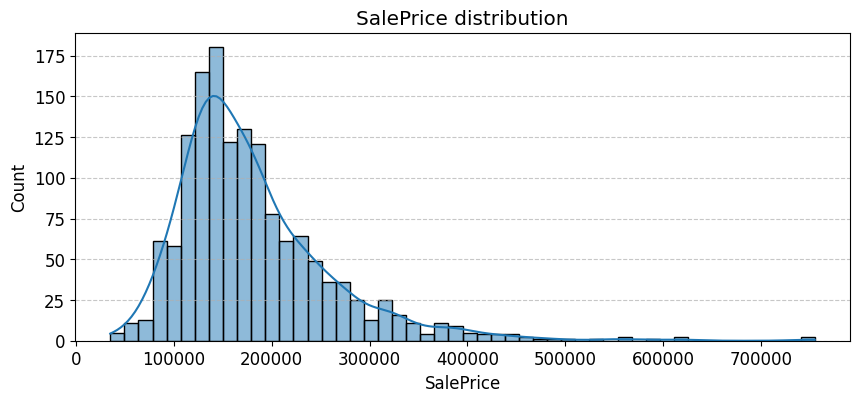

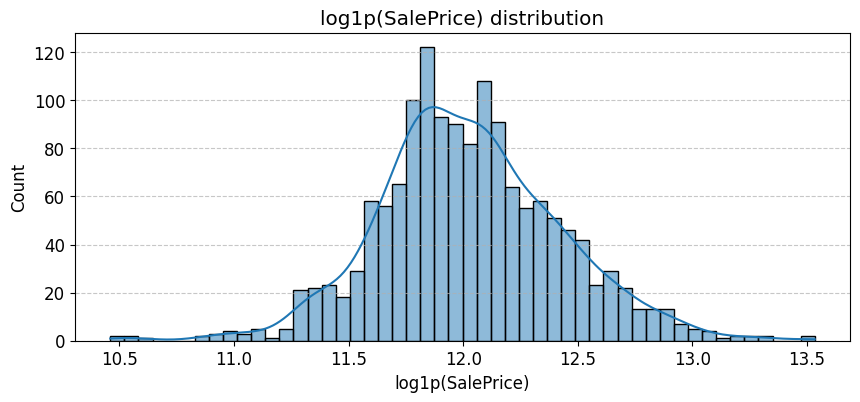

**Outliers (boxplots)**

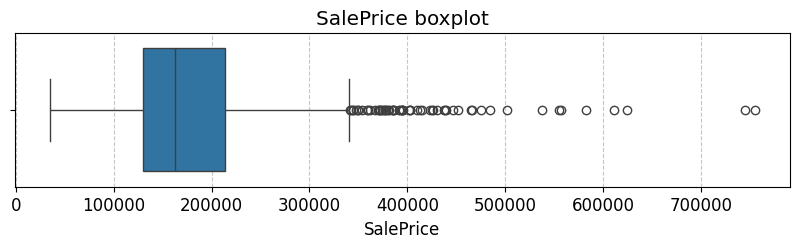

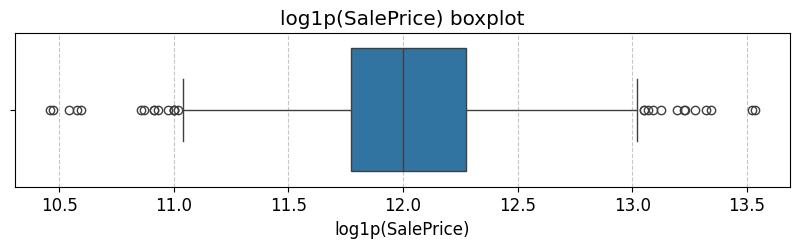

In [5]:
y = train_data["SalePrice"].copy()
y_log = np.log1p(y)

md("**Summary statistics**")
display(y.describe().to_frame("SalePrice"))

show_kv("Skewness (SalePrice)", round(y.skew(), 3))
show_kv("Skewness (log1p(SalePrice))", round(y_log.skew(), 3))

md("**Distributions**")
plt.figure(figsize = (10, 4))
sns.histplot(y, bins = 50, kde = True)
plt.title("SalePrice distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

plt.figure(figsize = (10, 4))
sns.histplot(y_log, bins = 50, kde = True)
plt.title("log1p(SalePrice) distribution")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

md("**Outliers (boxplots)**")
plt.figure(figsize = (10, 2))
sns.boxplot(x = y)
plt.title("SalePrice boxplot")
plt.xlabel("SalePrice")
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
plt.show()

plt.figure(figsize = (10, 2))
sns.boxplot(x = y_log)
plt.title("log1p(SalePrice) boxplot")
plt.xlabel("log1p(SalePrice)")
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
plt.show()

#### Key observations and implications
- The SalePrice distribution is strongly right-skewed: most observations are concentrated in the mid-price range, with a long right tail representing a small number of high-priced properties.
- After applying the `log1p(SalePrice)` transformation, the distribution becomes substantially more symmetric and closer to a bell-shaped form, while the influence of extremely high prices is visually reduced (outliers are compressed on the scale).
- Log-transforming the target appears justified for model training and comparison, particularly when using RMSLE as the evaluation metric, where relative errors are more important than absolute ones.

### Numerical features: structure and distributions

**Numerical features: summary statistics**

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


**Distributions (selected numerical features)**

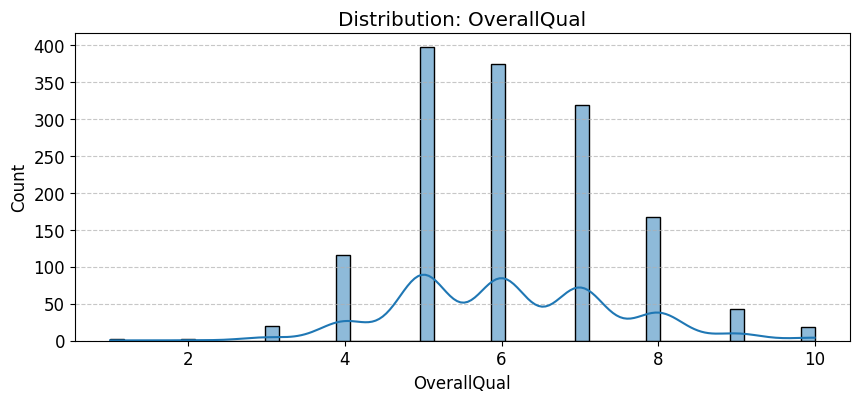

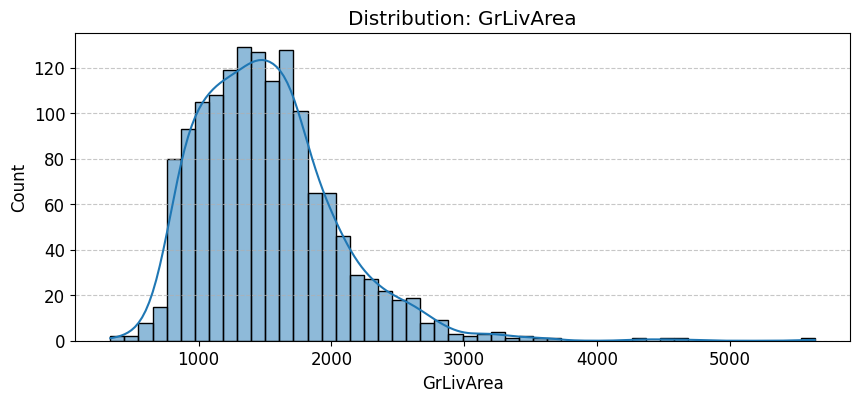

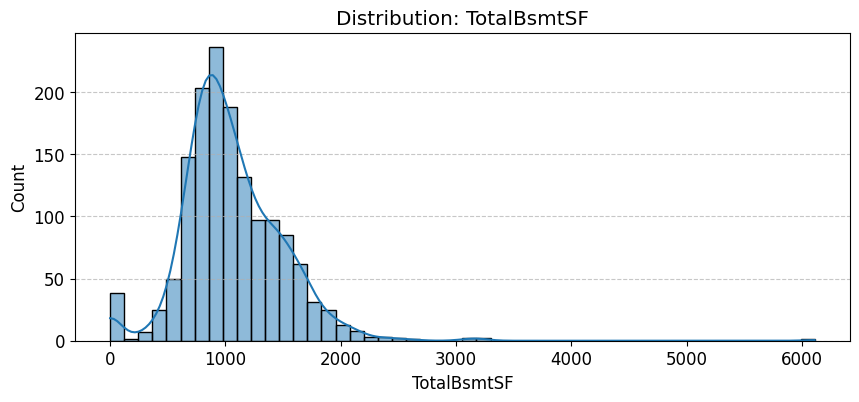

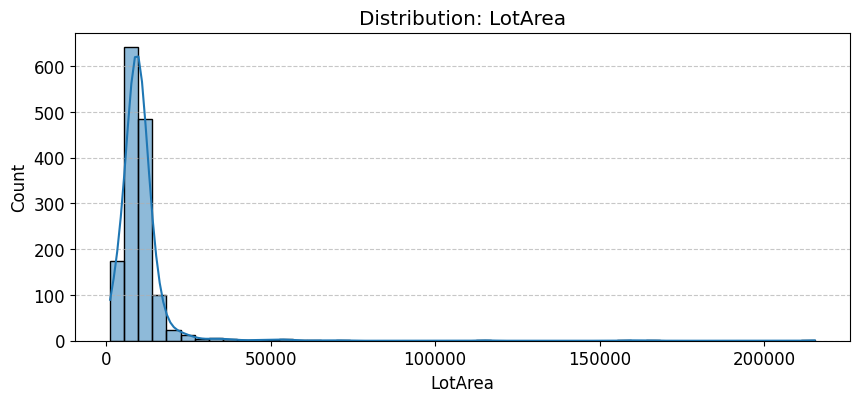

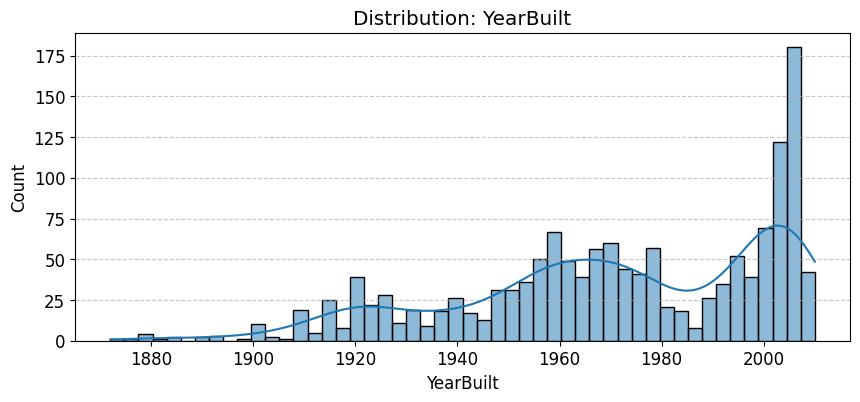

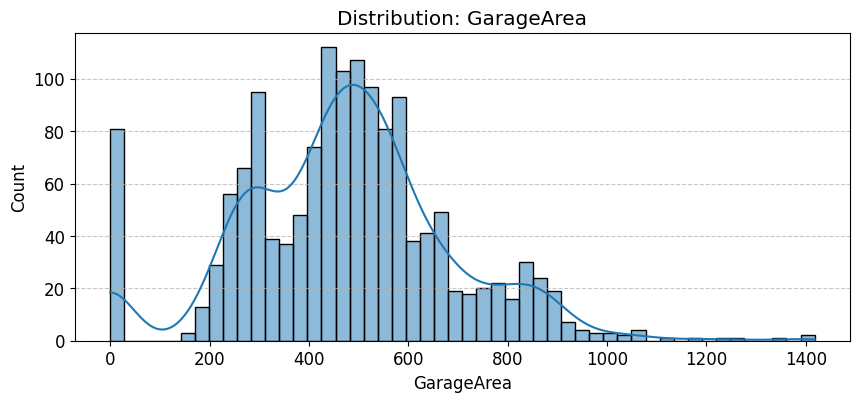

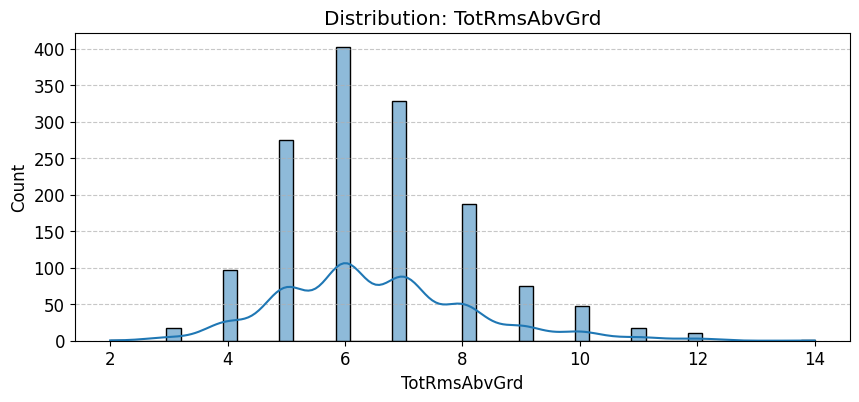

**Outliers (boxplots, selected numerical features)**

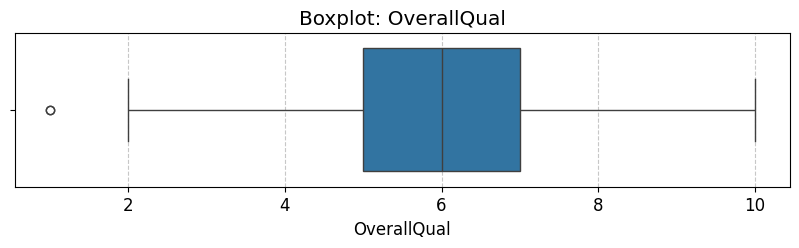

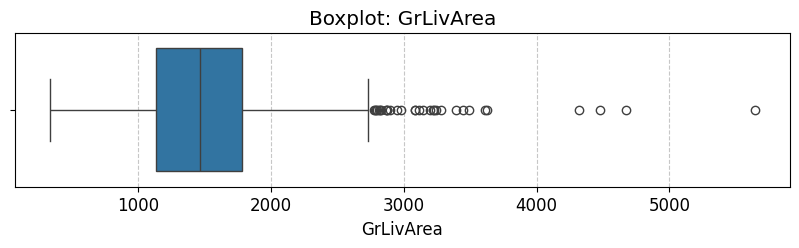

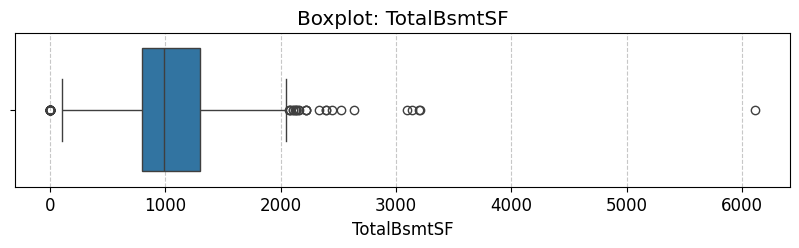

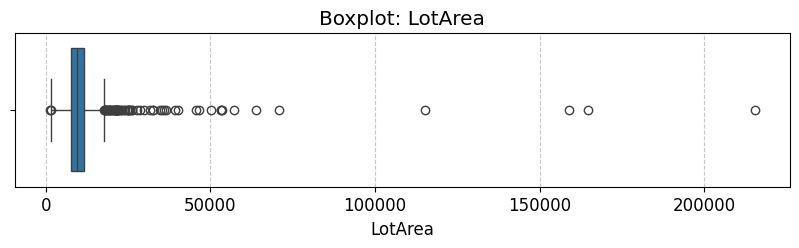

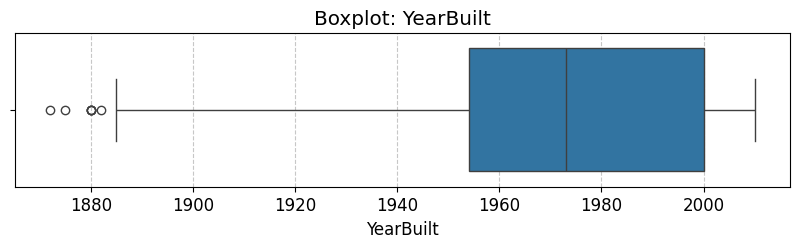

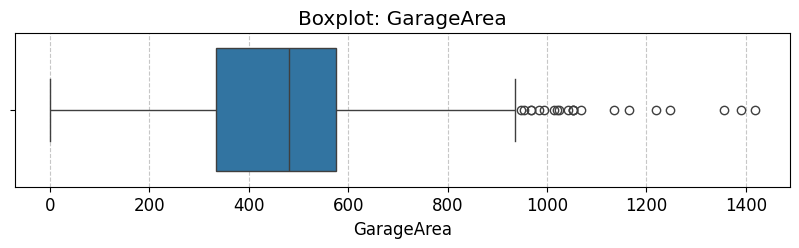

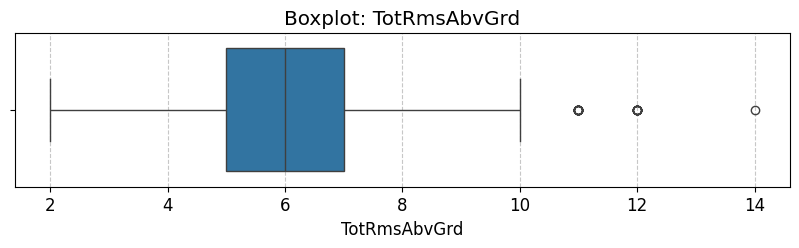

In [6]:
num_cols = train_data.select_dtypes(include = ["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["SalePrice", "Id"]]

md("**Numerical features: summary statistics**")
display(train_data[num_cols].describe().T)

NUM_PLOT_COLS = ["OverallQual", "GrLivArea", "TotalBsmtSF", "LotArea", "YearBuilt", "GarageArea", "TotRmsAbvGrd"]
NUM_PLOT_COLS = [c for c in NUM_PLOT_COLS if c in train_data.columns]

md("**Distributions (selected numerical features)**")
for col in NUM_PLOT_COLS:
    plt.figure(figsize = (10, 4))
    sns.histplot(train_data[col].dropna(), bins = 50, kde = True)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.show()

md("**Outliers (boxplots, selected numerical features)**")
for col in NUM_PLOT_COLS:
    plt.figure(figsize = (10, 2))
    sns.boxplot(x = train_data[col])
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
    plt.show()

#### Key observations and implications

- Numerical features exhibit substantial variation in scale and distribution. Area-related variables (e.g. `LotArea`, `GrLivArea`, `TotalBsmtSF`, `GarageArea`) span several orders of magnitude and show pronounced right skewness.
- Many numerical features contain extreme values and long tails, which are typical for real estate data and are especially visible in land and floor area variables.
- Several features have a large mass at zero (e.g. basement- and garage-related variables), reflecting the absence of corresponding property components rather than measurement noise.
- Temporal features such as `YearBuilt` and `YearRemodAdd` display more compact, structured distributions, capturing the age profile of the housing stock.
- Discrete count-like variables (e.g. `TotRmsAbvGrd`, number of bathrooms, fireplaces) exhibit limited ranges and stepwise distributions.
- The observed heterogeneity in scale and distribution motivates the use of feature scaling for scale-sensitive models, careful handling of zero-inflated variables, and a comparison of linear models with regularization against tree-based and boosting methods, which are generally more robust to skewness and outliers.

### Relationship between numerical features and target

**Top numerical features by correlation with `log1p(SalePrice)`**

,pearson_corr_with_log_target,spearman_corr_with_log_target
OverallQual,0.817185,0.809829
GrLivArea,0.700927,0.731310
GarageCars,0.680625,0.690711
GarageArea,0.650888,0.649379
TotalBsmtSF,0.612134,0.602725
1stFlrSF,0.596981,0.575408
FullBath,0.594771,0.635957
YearBuilt,0.586570,0.652682
YearRemodAdd,0.565608,0.571159
GarageYrBlt,0.541073,0.593788


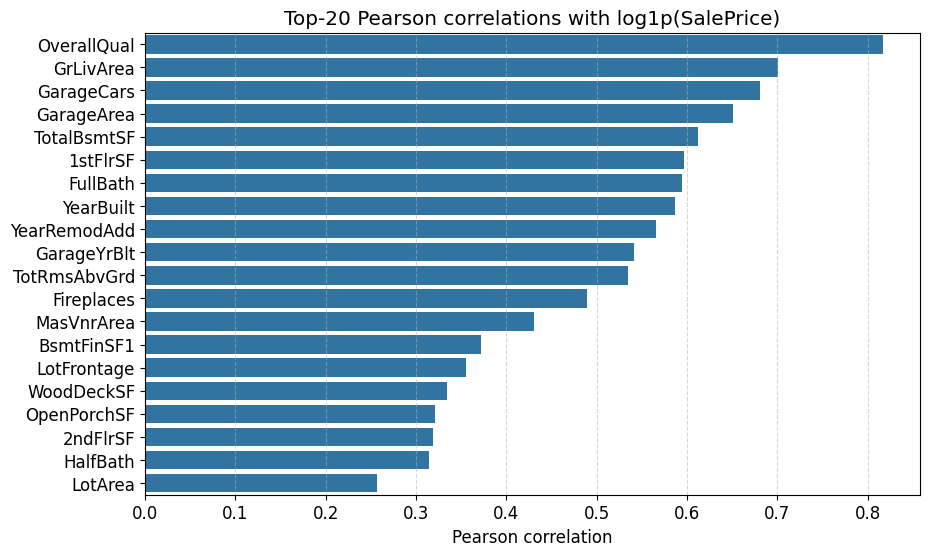

In [7]:
tmp = train_data.copy()
tmp["SalePrice_log"] = np.log1p(tmp["SalePrice"])

# Pearson (linear)
pearson_corr = (tmp[num_cols + ["SalePrice_log"]]
                .corr(method = "pearson", numeric_only = True)["SalePrice_log"]
                .drop("SalePrice_log")
                .sort_values(ascending = False))

# Spearman (monotonic / rank-based)
spearman_corr = (tmp[num_cols + ["SalePrice_log"]]
                 .corr(method = "spearman", numeric_only = True)["SalePrice_log"]
                 .drop("SalePrice_log")
                 .sort_values(ascending = False))

corr_table = (pd.DataFrame({"pearson_corr_with_log_target": pearson_corr, "spearman_corr_with_log_target": spearman_corr})
              .sort_values(by = "pearson_corr_with_log_target", ascending = False))

md("**Top numerical features by correlation with `log1p(SalePrice)`**")
display(corr_table)

# Barplot: Top-20 Pearson
top20 = pearson_corr.head(20)

plt.figure(figsize = (10, 6))
sns.barplot(
    x = top20.values,
    y = top20.index,
    orient = "h")

plt.title("Top-20 Pearson correlations with log1p(SalePrice)")
plt.xlabel("Pearson correlation")
plt.ylabel("")
plt.grid(axis = "x", linestyle = "--", alpha = 0.5)
plt.show()

#### Key observations and implications

- Pearson and Spearman correlations provide complementary views of the relationship between numerical features and `log1p(SalePrice)`. Pearson primarily reflects linear effects, while Spearman captures more general monotonic relationships and is less sensitive to outliers and non-linear scaling.
- Size-, capacity-, and quality-related features (e.g. `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`) exhibit the strongest associations with price under both correlation measures, confirming their central role in residential price formation.
- For several features (notably `LotArea`, `FullBath`, and `GarageYrBlt`), Spearman correlation exceeds Pearson correlation, indicating non-linear but monotonic relationships and diminishing marginal effects at higher values. This pattern is consistent with economic intuition in real estate markets.
- Temporal features (`YearBuilt`, `YearRemodAdd`) show positive but moderate associations with price: newer and more recently remodeled properties tend to sell at higher prices on average, although these effects are weaker and more dispersed than those of size and quality.
- Several numerical variables (e.g. `BsmtFinSF2`, `BsmtHalfBath`, `3SsnPorch`) display near-zero correlation with the target, suggesting limited standalone explanatory power and a higher likelihood of contributing only through interactions or in combination with other features.
- Overall, the observed dependency patterns indicate that:
    - linear models may be sensitive to non-linear effects and multicollinearity,
    - tree-based and boosting methods are better suited to capturing diminishing returns, heterogeneous variance, and feature interactions,
    - the use of a log-transformed target variable is well justified and leads to more stable, interpretable relationships under the chosen RMSLE evaluation metric.
- All correlation-based results should be interpreted as univariate exploratory signals rather than definitive measures of feature importance; final feature relevance must be validated through cross-validated, multivariate models.

### Correlation analysis and multicollinearity (numerical features)

**Top correlated numerical feature pairs**

,,abs_corr
GarageArea,GarageCars,0.882475
GarageYrBlt,YearBuilt,0.825667
TotRmsAbvGrd,GrLivArea,0.825489
1stFlrSF,TotalBsmtSF,0.819530
GrLivArea,2ndFlrSF,0.687501
TotRmsAbvGrd,BedroomAbvGr,0.676620
BsmtFullBath,BsmtFinSF1,0.649212
GarageYrBlt,YearRemodAdd,0.642277
FullBath,GrLivArea,0.630012
TotRmsAbvGrd,2ndFlrSF,0.616423


**Correlation heatmap (numerical features, lower triangle only)**

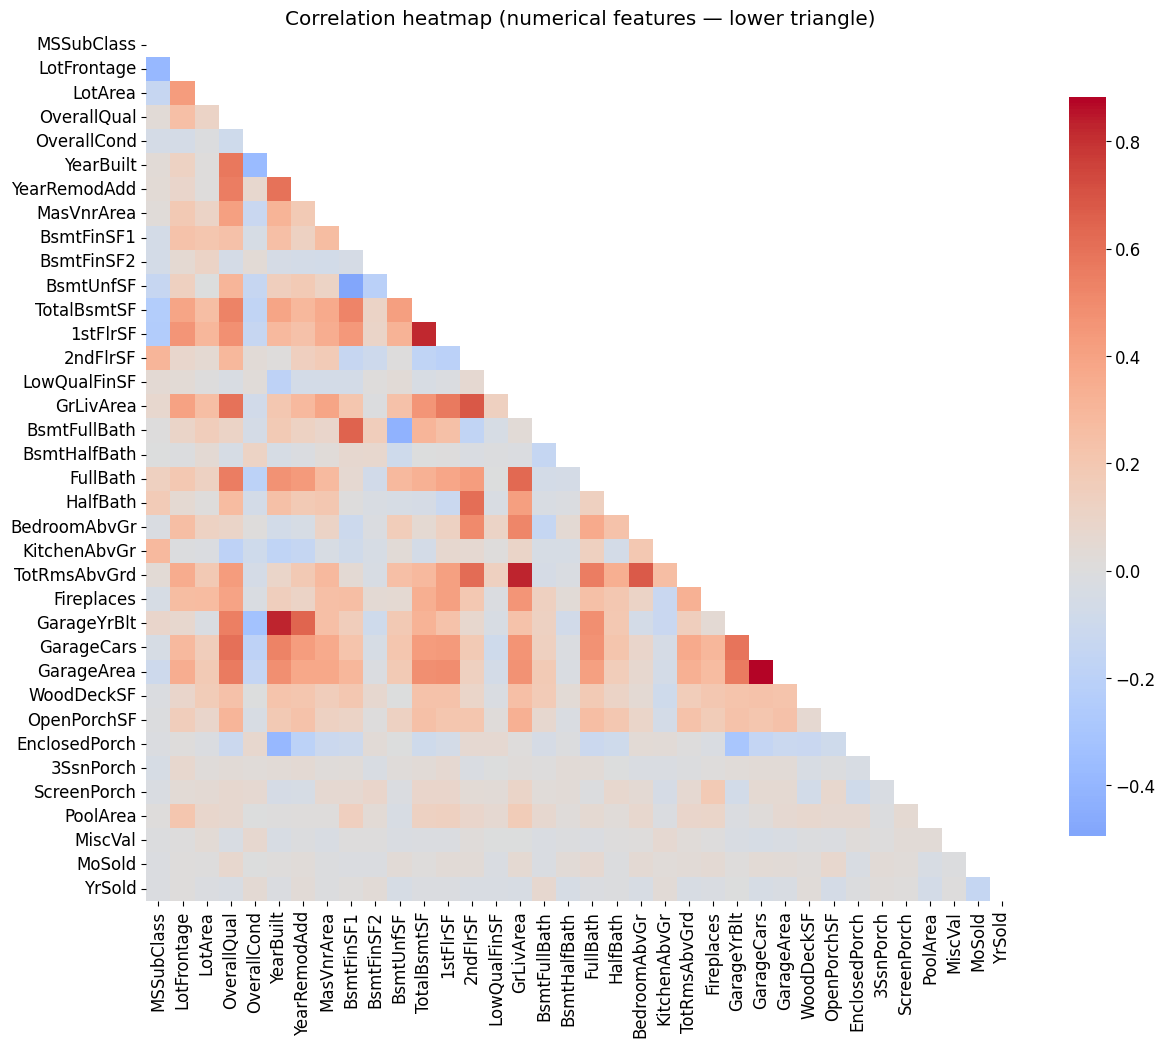

In [8]:
corr_matrix = train_data[num_cols].corr(numeric_only=True)

triangle = corr_matrix.abs().where(
    np.tril(np.ones(corr_matrix.shape), k = -1).astype(bool))

top_pairs = (
    triangle.stack().sort_values(ascending = False).head(20).to_frame("abs_corr"))

md("**Top correlated numerical feature pairs**")
display(top_pairs)

mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

md("**Correlation heatmap (numerical features, lower triangle only)**")
plt.figure(figsize = (14, 12))
sns.heatmap(corr_matrix, mask = mask, cmap = "coolwarm", center = 0, cbar_kws = {"shrink": 0.8}, square = True)

plt.title("Correlation heatmap (numerical features — lower triangle)")
plt.show()

#### Key observations and implications

- Several numerical features exhibit strong pairwise correlations, primarily reflecting different measurements of the same underlying property characteristics rather than independent sources of information.
- Size- and layout-related variables are highly correlated with each other. For example, `GrLivArea`, `TotRmsAbvGrd`, `1stFlrSF`, and `2ndFlrSF` show strong mutual relationships, indicating that total living area, room count, and floor-level areas capture overlapping aspects of house size.
- Garage-related features (`GarageArea`, `GarageCars`, `GarageYrBlt`) form a tightly correlated group. This suggests that garage size, capacity, and construction year are closely linked and largely describe a single latent factor related to garage availability and quality.
- Temporal variables (`YearBuilt`, `YearRemodAdd`, `GarageYrBlt`) also display strong correlations, reflecting the natural dependency between the construction year of the house, subsequent remodeling, and the garage build year.
- Correlations between quality indicators and size-related features (e.g. `OverallQual` with `GrLivArea` and `GarageCars`) indicate that larger houses tend to be of higher overall quality on average, though these relationships are notably weaker than correlations within the same feature groups.
- The presence of multiple highly correlated feature pairs implies a non-negligible degree of multicollinearity within the numerical feature set. This should be taken into account during modeling, particularly for linear models, while tree-based and ensemble methods are expected to be more robust to such redundancy.

### Categorical features: distribution and target impact

**Count plots (top categories)**

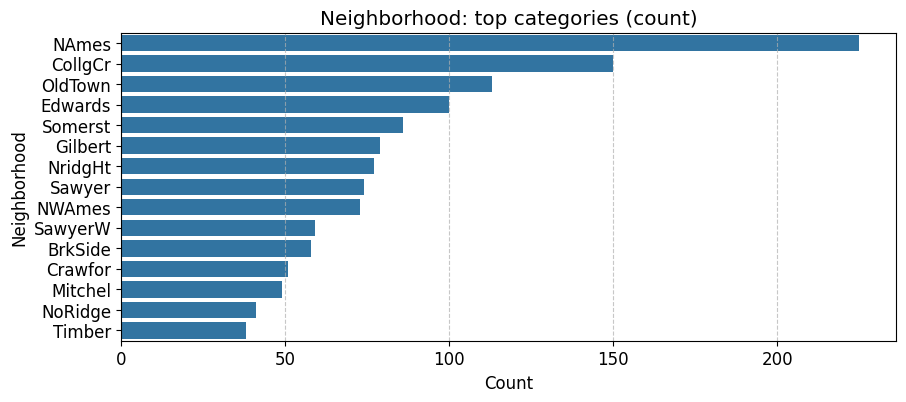

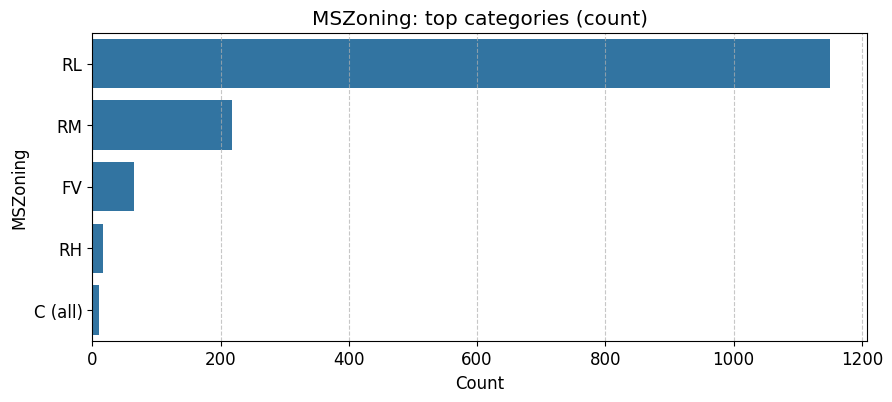

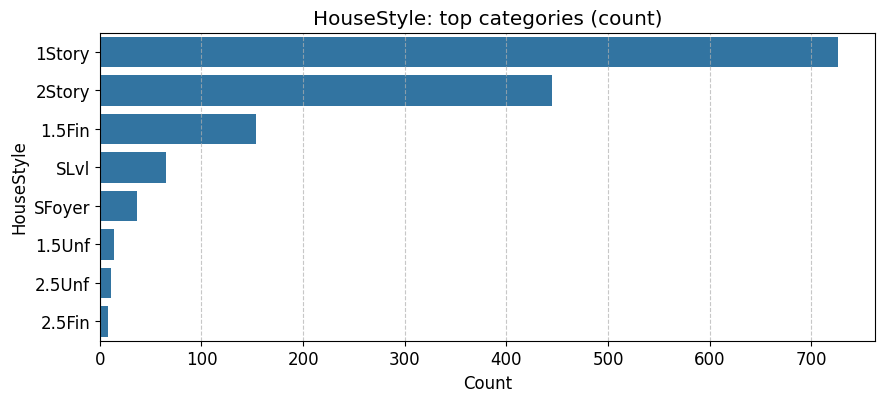

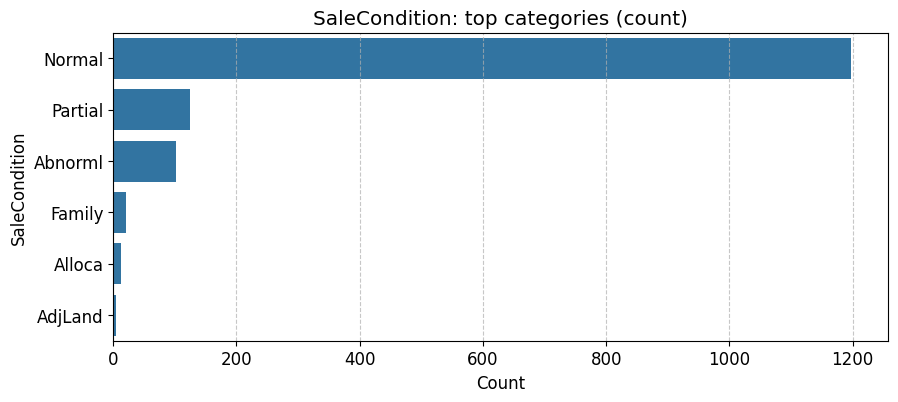

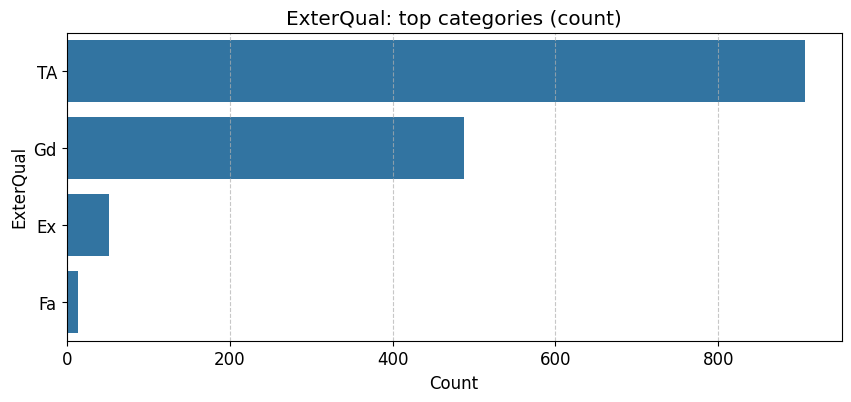

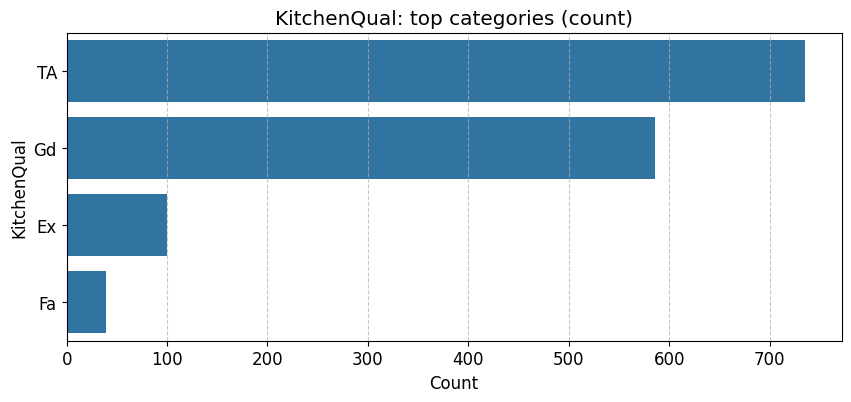

**Target by category (boxplots, top categories)**

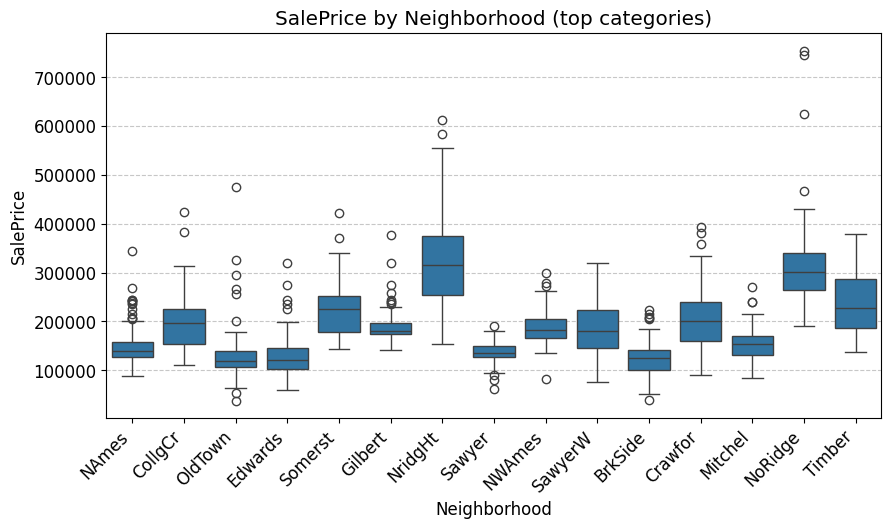

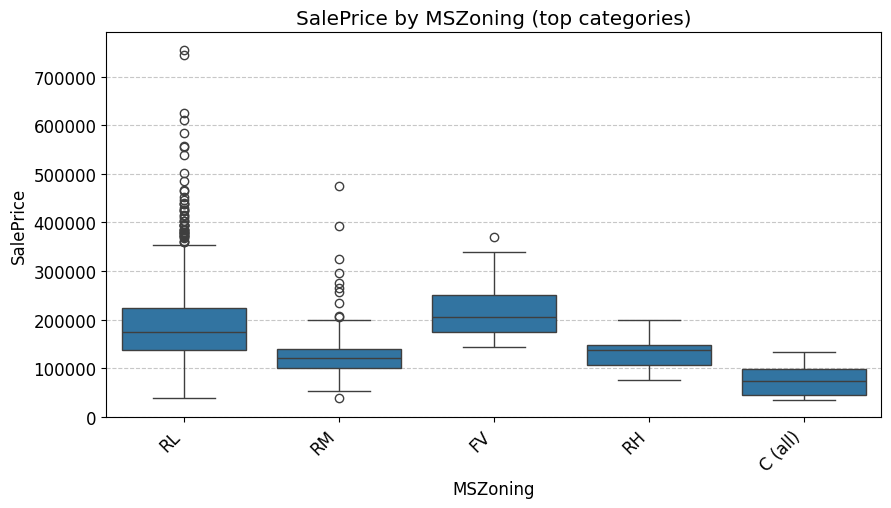

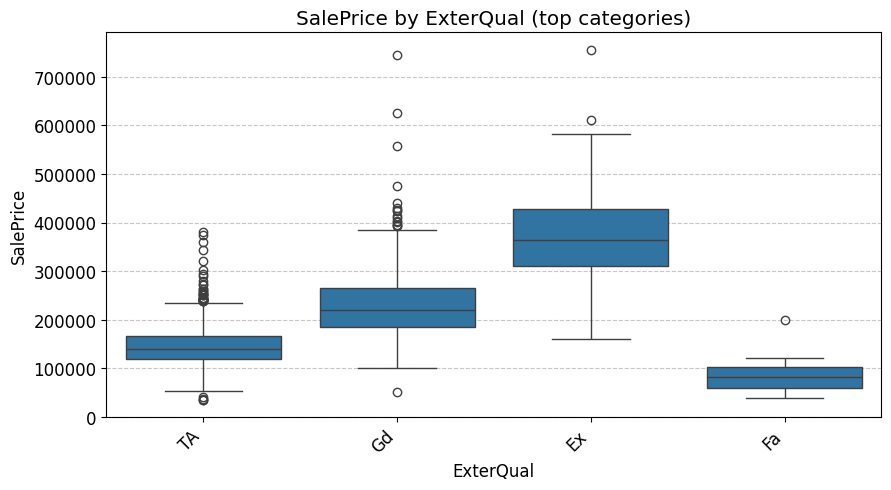

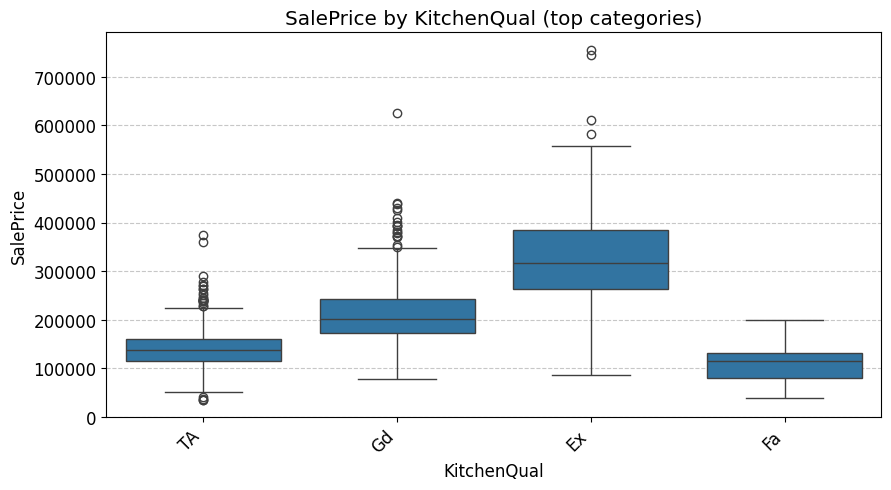

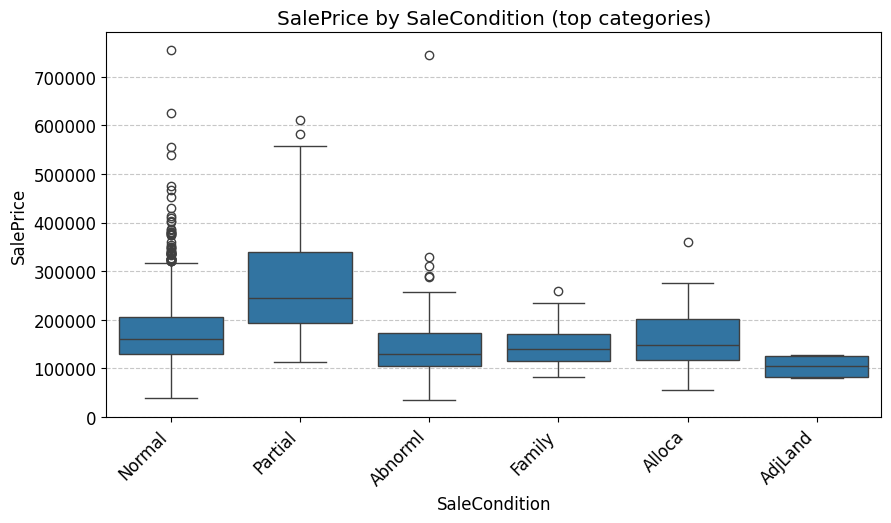

In [9]:
cat_cols = train_data.select_dtypes(include = ["object"]).columns.tolist()

CAT_COUNT_COLS = ["Neighborhood", "MSZoning", "HouseStyle", "SaleCondition", "ExterQual", "KitchenQual"]
CAT_COUNT_COLS = [c for c in CAT_COUNT_COLS if c in train_data.columns]

md("**Count plots (top categories)**")
for col in CAT_COUNT_COLS:
    top_levels = train_data[col].value_counts(dropna = False).head(15).index
    tmp = train_data[train_data[col].isin(top_levels)].copy()

    plt.figure(figsize = (10, 4))
    sns.countplot(data = tmp, y = col, order = tmp[col].value_counts().index)
    plt.title(f"{col}: top categories (count)")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
    plt.show()

CAT_TARGET_COLS = ["Neighborhood", "MSZoning", "ExterQual", "KitchenQual", "SaleCondition"]
CAT_TARGET_COLS = [c for c in CAT_TARGET_COLS if c in train_data.columns]

md("**Target by category (boxplots, top categories)**")
for col in CAT_TARGET_COLS:
    top_levels = train_data[col].value_counts(dropna = True).head(15).index
    tmp = train_data[train_data[col].isin(top_levels)].copy()

    plt.figure(figsize = (10, 5))
    sns.boxplot(data = tmp, x = col, y = "SalePrice", order = top_levels)
    plt.title(f"SalePrice by {col} (top categories)")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.xticks(rotation = 45, ha = "right")
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.show()

**Median SalePrice by category (top categories)**

,median_SalePrice
Neighborhood,
NridgHt,315000.0
NoRidge,301500.0
Timber,228475.0
Somerst,225500.0
Crawfor,200624.0
CollgCr,197200.0
NWAmes,182900.0
Gilbert,181000.0
SawyerW,179900.0


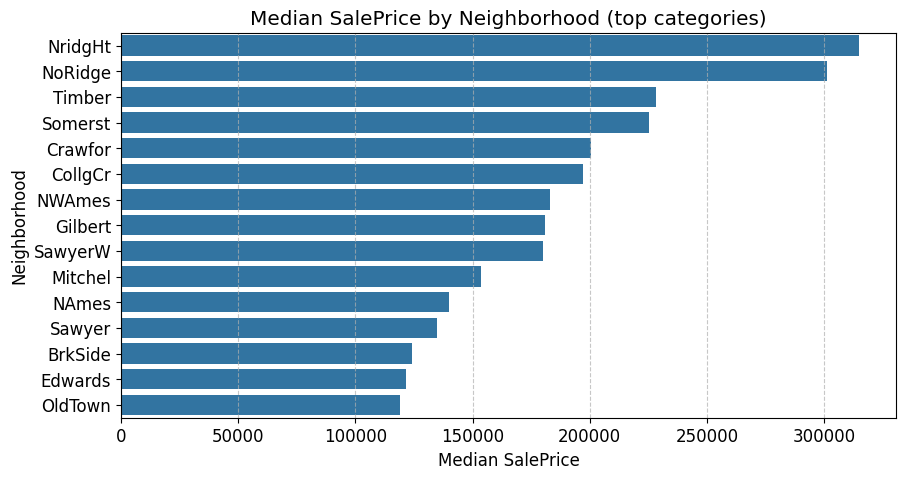

,median_SalePrice
MSZoning,
FV,205950.0
RL,174000.0
RH,136500.0
RM,120500.0
C (all),74700.0


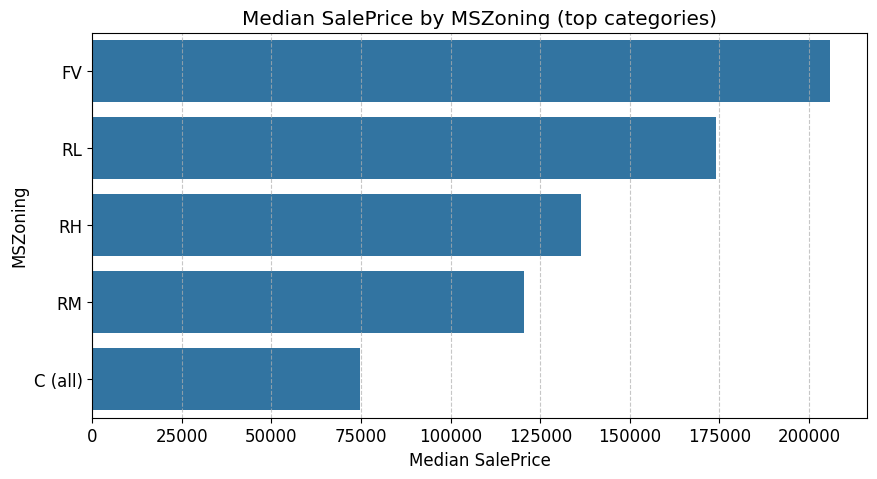

,median_SalePrice
ExterQual,
Ex,364606.5
Gd,220000.0
TA,139450.0
Fa,82250.0


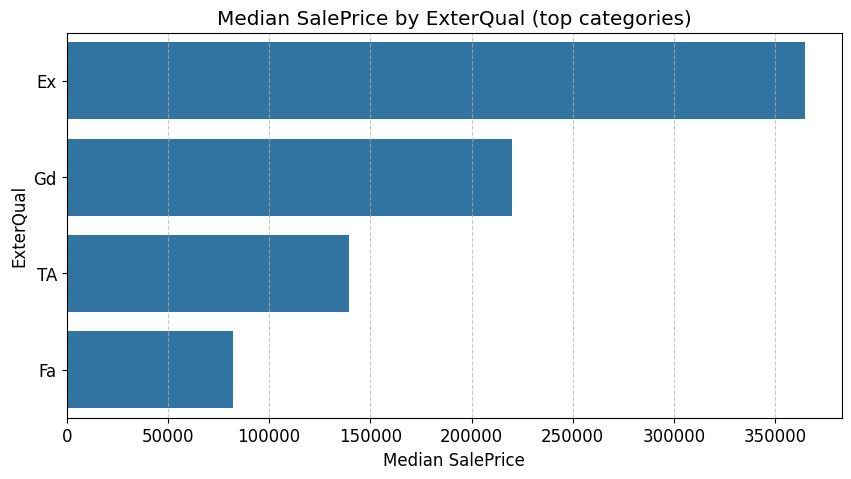

,median_SalePrice
KitchenQual,
Ex,316750.0
Gd,201400.0
TA,137000.0
Fa,115000.0


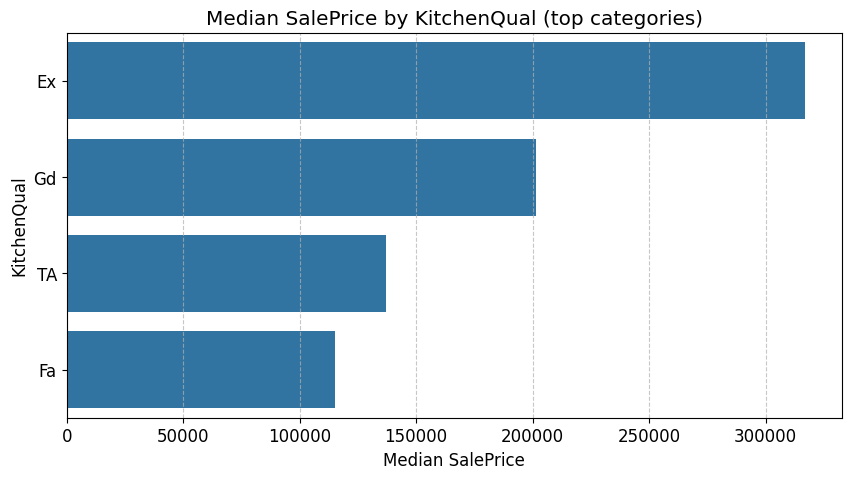

,median_SalePrice
SaleCondition,
Partial,244600.0
Normal,160000.0
Alloca,148145.0
Family,140500.0
Abnorml,130000.0
AdjLand,104000.0


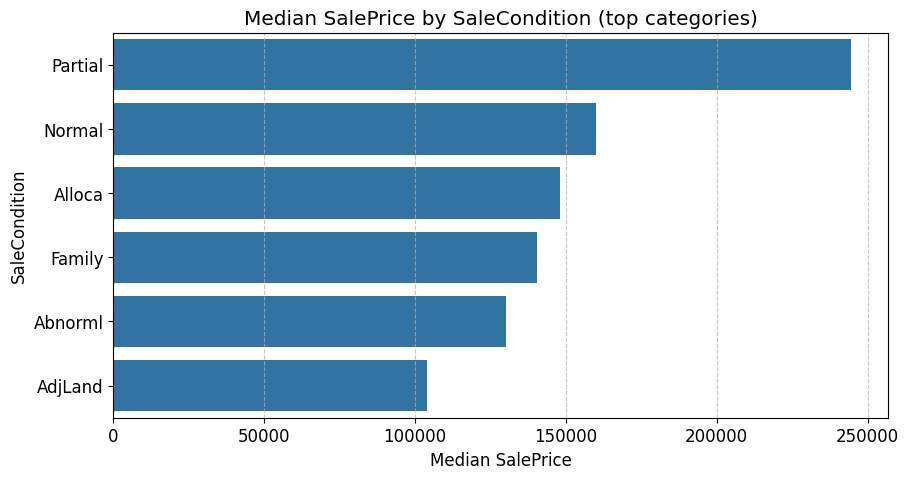

In [10]:
md("**Median SalePrice by category (top categories)**")
for col in CAT_TARGET_COLS:
    top_levels = train_data[col].value_counts(dropna = True).head(15).index
    med = (
        train_data[train_data[col].isin(top_levels)]
        .groupby(col)["SalePrice"]
        .median()
        .sort_values(ascending = False))
    display(med.to_frame("median_SalePrice"))

    plt.figure(figsize = (10, 5))
    sns.barplot(x = med.values, y = med.index)
    plt.title(f"Median SalePrice by {col} (top categories)")
    plt.xlabel("Median SalePrice")
    plt.ylabel(col)
    plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
    plt.show()

#### Key observations and implications
- Categorical features exhibit highly imbalanced level distributions, with one or two dominant categories and a long tail of infrequent values across most features.
- The Neighborhood feature shows the strongest differentiation in price levels across categories. Median prices vary substantially between neighborhoods, while within-category distributions partially overlap, indicating the joint influence of location and other property characteristics.
- Quality-related features (`ExterQual`, `KitchenQual`) display a stable ordering of median prices across category levels. Differences are evident not only in medians but across the full distribution range, confirming their strong explanatory power.
- Regulatory and transaction-related features (`MSZoning`, `SaleCondition`) are associated with weaker price differentiation and larger within-category variability, making their effects less stable compared to quality- and location-driven features.
- For categories with a limited number of observations, median estimates are sensitive to individual transactions, which should be considered when interpreting category-level effects.

### Categorical features: quantitative association with the target

In [11]:
tmp = train_data.copy()
tmp["SalePrice_log"] = np.log1p(tmp["SalePrice"])

def eta_squared(y: pd.Series, g: pd.Series) -> float:
    '''The function computes eta-squared as a measure of association between a categorical feature and a continuous target.'''
    
    df = pd.DataFrame({"y": y, "g": g}).dropna()
    if df["g"].nunique() < 2:
        return np.nan

    y_mean = df["y"].mean()
    ss_total = ((df["y"] - y_mean) ** 2).sum()

    grp = df.groupby("g")["y"].agg(["count", "mean"])
    ss_between = (grp["count"] * (grp["mean"] - y_mean) ** 2).sum()

    return float(ss_between / ss_total) if ss_total > 0 else np.nan

rows = []
for col in cat_cols:
    rows.append({"feature": col,
                 "n_levels": int(tmp[col].nunique(dropna = False)),
                 "eta2_log_target": eta_squared(tmp["SalePrice_log"], tmp[col])})

cat_eta = (pd.DataFrame(rows).sort_values("eta2_log_target", ascending = False))

md("**Top categorical features by eta-squared (log target)**")
display(cat_eta.head(20))

**Top categorical features by eta-squared (log target)**

,feature,n_levels,eta2_log_target
8,Neighborhood,25,0.570808
18,ExterQual,4,0.461123
38,PoolQC,4,0.460201
30,KitchenQual,4,0.447640
21,BsmtQual,5,0.435378
34,GarageFinish,4,0.323452
20,Foundation,6,0.303651
33,GarageType,7,0.269220
27,HeatingQC,5,0.233517
2,Alley,3,0.232808


#### Key observations and implications

- `Neighborhood` exhibits the strongest univariate association with the target variable, explaining a substantial share of variance in `log1p(SalePrice)`. This confirms location as the dominant categorical driver of house prices and justifies its prominent role in subsequent modeling.
- Quality-related categorical features (`ExterQual`, `KitchenQual`, `BsmtQual`, `HeatingQC`, `FireplaceQu`) consistently show high eta-squared values. This indicates that categorical assessments of construction and finish quality are strong differentiators of price levels, even when considered independently.
- `PoolQC` appears among the top features by eta-squared; however, this result should be interpreted with caution due to the very small number of non-missing observations. The high effect size likely reflects a rare but extreme price premium rather than a broadly applicable signal.
- Basement- and garage-related features (`BsmtQual`, `BsmtFinType1`, `BsmtExposure`, `GarageFinish`, `GarageType`) demonstrate moderate to strong associations with price, suggesting that the presence, quality, and finishing of auxiliary spaces meaningfully contribute to property valuation.
- Structural and regulatory features such as `Foundation`, `MSZoning`, and `SaleCondition` show weaker but non-negligible associations, indicating that they influence price primarily in combination with other characteristics rather than as standalone drivers.
- Features with relatively lower eta-squared values (e.g. `CentralAir`, `SaleType`) still exhibit detectable univariate effects but are likely to play a secondary role and derive most of their predictive value through interactions captured by multivariate models.
- Overall, these eta-squared values quantify univariate association strength only. High values indicate strong between-category price differentiation but do not imply causal impact or guarantee importance in a multivariate predictive model. Final feature relevance should therefore be assessed through cross-validated modeling.

### Missing values analysis

**Missing values (train set): counts and percentages**

,missing_count,missing_pct
PoolQC,1453,0.9952
MiscFeature,1406,0.9630
Alley,1369,0.9377
Fence,1179,0.8075
MasVnrType,872,0.5973
FireplaceQu,690,0.4726
LotFrontage,259,0.1774
GarageType,81,0.0555
GarageYrBlt,81,0.0555
GarageFinish,81,0.0555


**Missing values (train set): top features (bar plot)**

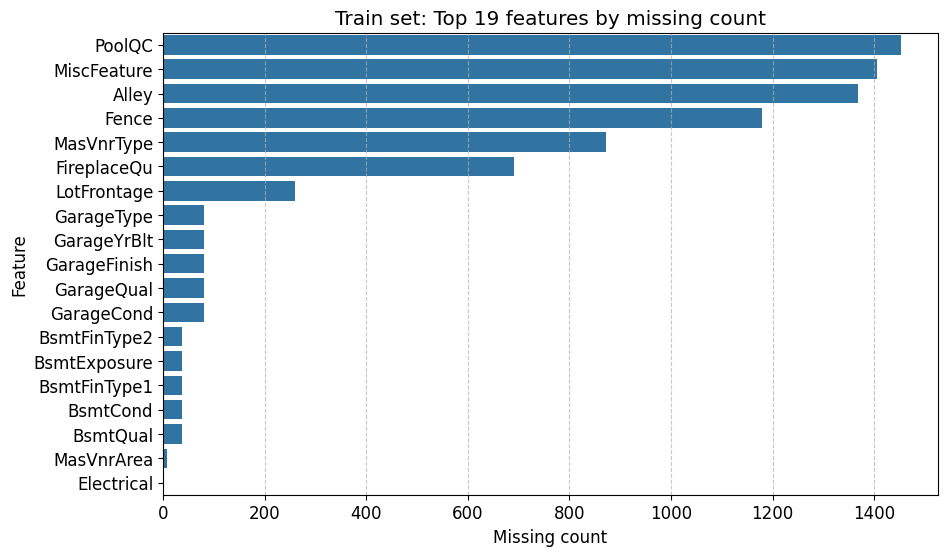

In [12]:
missing = train_data.isna().sum()
missing = missing[missing > 0].sort_values(ascending = False)
missing_pct = (missing / len(train_data)).round(4)

missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

md("**Missing values (train set): counts and percentages**")
display(missing_table)

md("**Missing values (train set): top features (bar plot)**")
top_n = min(20, len(missing_table))
plt.figure(figsize = (10, 6))
sns.barplot(x = missing_table.head(top_n)["missing_count"], y = missing_table.head(top_n).index)
plt.title(f"Train set: Top {top_n} features by missing count")
plt.xlabel("Missing count")
plt.ylabel("Feature")
plt.grid(axis = 'x', linestyle = '--', alpha = 0.7)
plt.show()

**Missing values (test set): counts and percentages**

,missing_count,missing_pct
PoolQC,1456,0.9979
MiscFeature,1408,0.9650
Alley,1352,0.9267
Fence,1169,0.8012
MasVnrType,894,0.6127
FireplaceQu,730,0.5003
LotFrontage,227,0.1556
GarageCond,78,0.0535
GarageYrBlt,78,0.0535
GarageQual,78,0.0535


**Missing values (test set): top features (bar plot)**

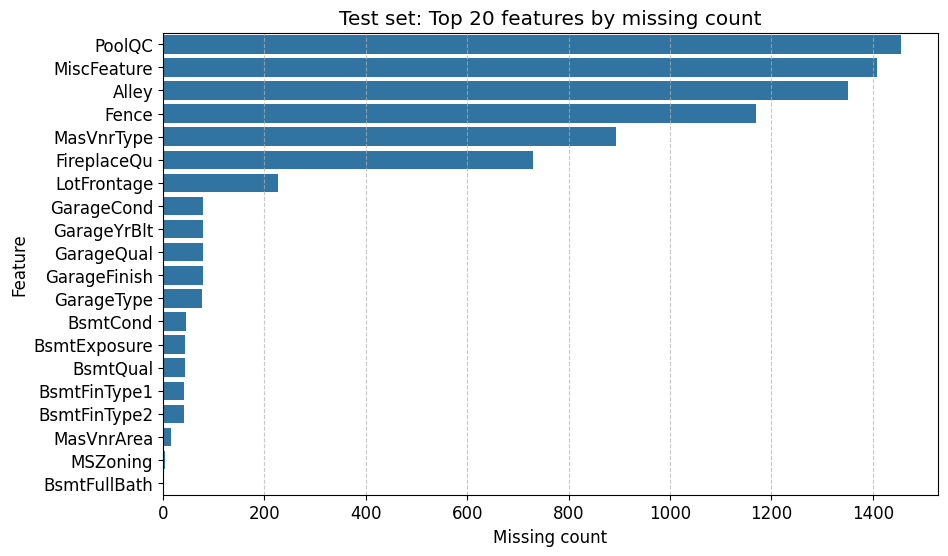

In [13]:
missing_test = test_data.isna().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending = False)
missing_test_pct = (missing_test / len(test_data)).round(4)

missing_test_table = pd.DataFrame({"missing_count": missing_test, "missing_pct": missing_test_pct})

md("**Missing values (test set): counts and percentages**")
display(missing_test_table)

md("**Missing values (test set): top features (bar plot)**")
top_n = min(20, len(missing_test_table))

plt.figure(figsize = (10, 6))
sns.barplot(
    x = missing_test_table.head(top_n)["missing_count"],
    y = missing_test_table.head(top_n).index)
plt.title(f"Test set: Top {top_n} features by missing count")
plt.xlabel("Missing count")
plt.ylabel("Feature")
plt.grid(axis = "x", linestyle = "--", alpha = 0.7)
plt.show()

#### Key observations and implications

- Missing values are highly concentrated in a limited subset of features and show very similar patterns in both the training and test sets, indicating stable and systematic missingness rather than random data loss.
- Several categorical features (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`) exhibit extremely high missing rates (≈80–99%) in both datasets. In these cases, missing values clearly correspond to the absence of the associated property component rather than unknown measurements.
- Basement- and garage-related features show moderate but consistent missingness across multiple related columns, forming coherent groups that represent shared structural states (e.g. no basement or no garage).
- A smaller set of features (e.g. `LotFrontage`, `MasVnrType`, `MasVnrArea`) exhibits partial missingness, where missing values occur only for a subset of observations and cannot be uniformly interpreted as structural absence. These features require explicit, feature-specific imputation rules.
- Although the test set contains more missing values and affects additional features, the semantic nature of missingness remains consistent across datasets, allowing for a shared preprocessing strategy fitted on the training data.
- Overall, the observed missingness structure indicates that generic imputation strategies (global mean or most-frequent) would distort feature semantics. Missing values should be handled using meaning-preserving, feature-aware rules that distinguish between absence and unknown values.

#### Summary of exploratory findings

- Exploratory analysis has provided a clear and consistent understanding of target behavior, feature distributions, and univariate relationships for both numerical and categorical variables.
- The target variable (`SalePrice`) is strongly right-skewed, and the log1p(SalePrice) transformation substantially stabilizes its distribution, aligning well with the RMSLE evaluation metric.
- Numerical features exhibit pronounced scale heterogeneity, skewness, and multicollinearity, supporting the use of scaling, regularization, and non-linear model families alongside linear baselines.
- Categorical features show substantial and interpretable price differentiation across levels, with location- and quality-related variables demonstrating the strongest univariate associations with the target.
- Missing values are systematic, interpretable, and largely consistent across train and test sets, making them an integral part of the feature space rather than noise.
- Overall, the EDA results form a solid foundation for designing a robust preprocessing pipeline, with particular emphasis on semantically correct missing value handling, appropriate encoding of categorical variables, and model-aware feature preparation.

<a id="data-preprocessing"></a>
## Data preprocessing

### Missing value handling

In [14]:
X_train = train_data.drop(["Id", "SalePrice"], axis = 1).copy()
X_test  = test_data.drop(["Id"], axis = 1).copy()

# Drop extremely sparse feature
for df in (X_train, X_test):
    if "MiscFeature" in df.columns:
        df.drop(columns = ["MiscFeature"], inplace = True)

# LotFrontage: fill by Neighborhood median
if "LotFrontage" in X_train.columns and "Neighborhood" in X_train.columns:
    neigh_median = X_train.groupby("Neighborhood")["LotFrontage"].median()
    global_median = X_train["LotFrontage"].median()

    def fill_lotfrontage(df: pd.DataFrame) -> None:
        '''The function fills missing LotFrontage values using neighborhood-level and global medians.'''
        
        df["LotFrontage"] = df["LotFrontage"].fillna(df["Neighborhood"].map(neigh_median))
        df["LotFrontage"] = df["LotFrontage"].fillna(global_median)

    fill_lotfrontage(X_train)
    fill_lotfrontage(X_test)

# Numeric features where NaN means "absence"
num_zero_cols = ["GarageYrBlt", "MasVnrArea", "GarageArea", "GarageCars", "TotalBsmtSF", 
                 "BsmtUnfSF", "BsmtFullBath", "BsmtHalfBath", "BsmtFinSF1", "BsmtFinSF2"]
for c in num_zero_cols:
    if c in X_train.columns:
        X_train[c] = X_train[c].fillna(0)
        X_test[c]  = X_test[c].fillna(0)

# Basement categorical block
bsmt_cat_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]

for df in (X_train, X_test):
    if "TotalBsmtSF" in df.columns:
        no_bsmt = (df["TotalBsmtSF"] == 0) | (df["TotalBsmtSF"].isna())
        for c in bsmt_cat_cols:
            if c in df.columns:
                df.loc[no_bsmt, c] = df.loc[no_bsmt, c].fillna("NoBsmt")
                df[c] = df[c].fillna("Unf")

# Garage categorical block
garage_cat_cols = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]

for df in (X_train, X_test):
    if "GarageArea" in df.columns:
        no_garage = (df["GarageArea"] == 0) | (df["GarageArea"].isna())
        for c in garage_cat_cols:
            if c in df.columns:
                df.loc[no_garage, c] = df.loc[no_garage, c].fillna("NoGarage")
                df[c] = df[c].fillna("Unf")

# PoolQC
for df in (X_train, X_test):
    if "PoolQC" in df.columns and "PoolArea" in df.columns:
        no_pool = (df["PoolArea"] == 0) | (df["PoolArea"].isna())
        df.loc[no_pool, "PoolQC"] = df.loc[no_pool, "PoolQC"].fillna("NoPool")
        df["PoolQC"] = df["PoolQC"].fillna("Unf")

# Direct "absence" categorical features
direct_absence = {"Alley": "NoAlley",
                  "MasVnrType": "NoMasVnr",
                  "FireplaceQu": "NoFireplace",
                  "Fence": "NoFence",}
for col, val in direct_absence.items():
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(val)
        X_test[col]  = X_test[col].fillna(val)


# Low-missing categorical features: fill with train mode
mode_fill_cols = ["MSZoning", "Utilities", "Exterior1st", "Exterior2nd", "SaleType", "Electrical", "KitchenQual", "Functional"]

for col in mode_fill_cols:
    if col in X_train.columns:
        mode_val = X_train[col].mode(dropna = True)
        mode_val = mode_val.iloc[0] if len(mode_val) > 0 else "Unf"
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col]  = X_test[col].fillna(mode_val)

# Final check: no NaNs remain
train_nan_cols = X_train.columns[X_train.isna().any()].tolist()
test_nan_cols  = X_test.columns[X_test.isna().any()].tolist()

if train_nan_cols or test_nan_cols:
    raise ValueError(f"NaNs remain. Train: {train_nan_cols} | Test: {test_nan_cols}")
else:
    md("Missing value handling completed.")

Missing value handling completed.

### Preprocessing setup

In [15]:
X_train['MSSubClass'] = X_train['MSSubClass'].astype(str)
X_test['MSSubClass'] = X_test['MSSubClass'].astype(str)

In [16]:
numerical_features = X_train.select_dtypes(include = ['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include = ['object']).columns.tolist()

In [17]:
num_scaler = StandardScaler()
cat_encoder = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)

In [18]:
# Preprocessing for scale-sensitive models & Preprocessing for PCA-based models
full_preprocessor = ColumnTransformer(
    transformers = [
        ("num", Pipeline(steps = [
            ("imputer", SimpleImputer(strategy = "median")),
            ("scaler", num_scaler),]), numerical_features),

        ("cat", Pipeline(steps = [
            ("imputer", SimpleImputer(strategy = "most_frequent")),
            ("onehot", cat_encoder),]), categorical_features),],
    
    remainder = "drop")

In [19]:
# Preprocessing for tree-based models
categorical_encoder = ColumnTransformer(
    transformers = [
        ("cat", cat_encoder, categorical_features)],
    remainder = "passthrough")

### Train/test split

In [20]:
X_train_train, X_train_test, y_train_log, y_test_log = train_test_split(X_train, y_log, test_size = 0.25, random_state = 42)
y_test = np.expm1(y_test_log)

### Model evaluation function

In [21]:
def evaluate_model(model, X_train_test, y_test, y_test_log, model_name: str):
    """The function evaluates a regressor trained on log-target and report metrics in original scale."""
    y_pred_log = model.predict(X_train_test)

    y_pred = np.expm1(y_pred_log)
    y_pred = np.asarray(y_pred)

    rmsle = rmsle_score(y_test, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = float(r2_score(y_test, y_pred))
    mae = float(mean_absolute_error(y_test, y_pred))

    md(f"**Model evaluation:** `{model_name}`")
    show_metrics(
        "Metrics (original scale)",
        {"RMSLE": rmsle, "RMSE ($)": rmse, "MAE ($)": mae, "R2": r2},
        round_n = 5)

    return {"RMSLE": rmsle, "RMSE ($)": rmse, "R2": r2, "MAE ($)": mae, "y_pred": y_pred}

In [22]:
results = {}
final_pipelines = {}
kf = KFold(5, shuffle = True, random_state = 42)

### Pipelines definition

In [23]:
def create_standard_pipeline(regressor_model):
    '''The function creates a standard pipeline using the full_preprocessor (scaling, encoding) and the specified regressor model.'''
    """ Пайплайн: full_preprocessor -> Regressor (для Ridge, Lasso, SVR, KNN)"""
    return Pipeline(steps = [
        ('preprocessor', full_preprocessor), 
        ('regressor', regressor_model)])

def create_tree_pipeline(regressor_model):
    '''The function creates a pipeline optimized for tree-based models, using only the categorical_encoder preprocessor and 
    the specified regressor model.'''
    """Пайплайн: categorical_encoder -> Regressor (для DecisionTree, XGB, LightGBM)"""
    return Pipeline(steps = [
        ('preprocessor', categorical_encoder), 
        ('regressor', regressor_model)])

def create_PCA_pipeline(regressor_model):
    '''The function creates a scikit-learn pipeline that chains the data preprocessor,
    Principal Component Analysis (PCA) for dimensionality reduction, and the specified regressor.'''
    return Pipeline(steps = [
        ('preprocessor', full_preprocessor),
        ('pca', PCA(random_state = 42)),
        ('regressor', regressor_model)])

def create_poly_pipeline(regressor_model):
    '''The function creates a scikit-learn pipeline for polynomial regression by chaining a preprocessor, 
    polynomial feature generation, and the specified regressor model.'''
    return Pipeline(steps = [('preprocessor', full_preprocessor), 
                           ('poly', PolynomialFeatures(include_bias = False)), 
                           ('regressor', regressor_model)])

def create_poly_PCA_pipeline(regressor_model):
    '''The function creates a pipeline for polynomial regression that applies the data preprocessor, PCA,
    Polynomial Features (degree = 2), and the specified regressor model.'''
    return Pipeline(steps = [
        ('preprocessor', full_preprocessor), 
        ('pca', PCA(random_state = 42)), 
        ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
        ('regressor', regressor_model)])

<a id="model-training-and-hyperparameter-tuning"></a>
## Model training & hyperparameter tuning

- Several model families are evaluated to capture different types of relationships between features and the target.
- Linear models are used as strong, interpretable baselines; regularized variants address multicollinearity explicitly.
- PCA is applied selectively for models that are sensitive to feature redundancy or computational complexity.
- Tree-based and boosting models are evaluated separately, as they are inherently robust to feature scaling and multicollinearity.

<a id="linear-models-baseline-and-regularized"></a>
## Linear models (baseline and regularized)

### Linear regression (OLS): full feature set - baseline

- Ordinary Least Squares is used as a baseline linear model on the full feature set. This configuration highlights the effect of multicollinearity and serves as a reference point for regularized and PCA-based variants.

In [24]:
pipeline_OLS = create_standard_pipeline(LinearRegression(n_jobs = -1))
pipeline_OLS.fit(X_train_train, y_train_log)

results["OLS"] = evaluate_model(pipeline_OLS, X_train_test, y_test, y_test_log, "OLS")
final_pipelines["OLS"] = pipeline_OLS

**Model evaluation:** `OLS`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.12904
1,RMSE ($),22542.62300
2,MAE ($),14788.78191
3,R2,0.92746


### Linear regression (OLS) with PCA

- PCA is applied prior to OLS to reduce feature redundancy and stabilize estimation in the presence of strong multicollinearity.

In [25]:
pipeline_OLS_PCA = create_PCA_pipeline(LinearRegression(n_jobs = -1))

param_grid_OLS_PCA = {'pca__n_components': [0.9, 0.95, 0.99]}

grid_search_OLS_PCA = GridSearchCV(
    pipeline_OLS_PCA, 
    param_grid_OLS_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_OLS_PCA.fit(X_train_train, y_train_log)
best_OLS_PCA = grid_search_OLS_PCA.best_estimator_

results['OLS_PCA'] = evaluate_model(best_OLS_PCA, X_train_test, y_test, y_test_log, 'OLS_PCA')
final_pipelines['OLS_PCA'] = best_OLS_PCA

show_search_results("OLS (PCA)", grid_search_OLS_PCA)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation:** `OLS_PCA`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.14097
1,RMSE ($),25692.23435
2,MAE ($),17133.14548
3,R2,0.90577


**Hyperparameter search:** `OLS (PCA)`

**Best RMSLE (CV):** `0.147`

**Best parameters**

,param,value
0,pca__n_components,0.99


### Ridge regression (L2 regularization): full feature set

- Ridge regression is trained on the full feature set. L2 regularization directly addresses multicollinearity by shrinking correlated coefficients, making additional dimensionality reduction unnecessary.

In [26]:
pipeline_ridge = create_standard_pipeline(Ridge(random_state = 42))

param_grid_ridge = {'regressor__alpha': [10.0, 15.0, 20.0, 25.0]}

grid_search_ridge = GridSearchCV(
    pipeline_ridge, 
    param_grid_ridge, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_ridge.fit(X_train_train, y_train_log)
best_ridge = grid_search_ridge.best_estimator_

results['Ridge'] = evaluate_model(best_ridge, X_train_test, y_test, y_test_log, 'Ridge')
final_pipelines['Ridge'] = best_ridge

show_search_results("Ridge", grid_search_ridge)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


**Model evaluation:** `Ridge`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.13360
1,RMSE ($),24859.52669
2,MAE ($),16171.57505
3,R2,0.91178


**Hyperparameter search:** `Ridge`

**Best RMSLE (CV):** `0.14681`

**Best parameters**

,param,value
0,regressor__alpha,15.0


### Lasso regression (L1 regularization): full feature set

- Lasso regression is evaluated on the full feature set to perform implicit feature selection via L1 regularization. PCA is intentionally not applied to preserve sparsity and interpretability.

In [27]:
pipeline_lasso = create_standard_pipeline(Lasso(random_state = 42, max_iter = 2000))

param_grid_lasso = {'regressor__alpha': [0.0005, 0.001, 0.005, 0.01, 0.05]}

grid_search_lasso = GridSearchCV(
    pipeline_lasso, 
    param_grid_lasso, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_lasso.fit(X_train_train, y_train_log)
best_lasso = grid_search_lasso.best_estimator_

results['Lasso'] = evaluate_model(best_lasso, X_train_test, y_test, y_test_log, 'Lasso')
final_pipelines['Lasso'] = best_lasso

show_search_results("Lasso", grid_search_lasso)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


**Model evaluation:** `Lasso`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.12375
1,RMSE ($),21790.36698
2,MAE ($),14414.88814
3,R2,0.93222


**Hyperparameter search:** `Lasso`

**Best RMSLE (CV):** `0.14736`

**Best parameters**

,param,value
0,regressor__alpha,0.0005


### Elastic net regression: full feature set

- Elastic Net combines L1 and L2 penalties, balancing coefficient shrinkage and feature selection. As with Ridge and Lasso, PCA is omitted since regularization already controls feature redundancy.

In [28]:
pipeline_elastic_net = create_standard_pipeline(ElasticNet(random_state = 42, max_iter = 2000))

param_grid_elastic_net = {
    'regressor__alpha': [0.0005, 0.001, 0.01, 0.1], 
    'regressor__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 1.0]}

grid_search_elastic_net = GridSearchCV(
    pipeline_elastic_net, 
    param_grid_elastic_net, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_elastic_net.fit(X_train_train, y_train_log)
best_elastic_net = grid_search_elastic_net.best_estimator_

results['ElasticNet'] = evaluate_model(best_elastic_net, X_train_test, y_test, y_test_log, 'ElasticNet')
final_pipelines['ElasticNet'] = best_elastic_net

show_search_results("ElasticNet", grid_search_elastic_net)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


**Model evaluation:** `ElasticNet`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.13016
1,RMSE ($),23807.44876
2,MAE ($),15602.23047
3,R2,0.91909


**Hyperparameter search:** `ElasticNet`

**Best RMSLE (CV):** `0.14671`

**Best parameters**

,param,value
0,regressor__alpha,0.001
1,regressor__l1_ratio,0.950


#### **Linear models analysis**

- This section evaluates linear models as baseline approaches to assess predictive performance and to analyze the effect of regularization in a high-dimensional, highly collinear feature space.

**Ordinary Least Squares (OLS)**
- OLS trained on the full feature set provides a strong baseline performance.
- This result indicates that, with proper preprocessing and log-transformation of the target variable, a simple linear model can explain a large share of price variability.
- However, OLS is highly sensitive to multicollinearity and overfitting, which limits its stability and robustness across different data splits.

**OLS with PCA**
- Applying PCA before OLS leads to a degradation in model performance.
- Although PCA reduces dimensionality and removes linear dependencies between features, it also discards interpretable and predictive information that is important for linear regression.
- This result suggests that multicollinearity is not the primary limiting factor for OLS performance, and aggressive dimensionality reduction is not beneficial in this setting.

**Ridge Regression (L2 regularization)**
- L2 regularization stabilizes coefficient estimates and mitigates multicollinearity, but in this case it does not outperform the OLS baseline.
- This indicates that simple coefficient shrinkage is insufficient to capture the underlying complexity of the data.

**Lasso Regression (L1 regularization)**
- Lasso regression with a very weak regularization delivers the best performance among all linear models.
- L1 regularization performs implicit feature selection by driving less informative coefficients to zero, reducing noise from redundant and sparse dummy variables.
- The extremely small optimal value of α suggests that:
    - strong shrinkage is not required,
    - but even mild feature selection provides a measurable performance gain.
- This makes Lasso a strong and interpretable linear benchmark.

**Elastic Net**
- Although the model behaves similarly to Lasso, the addition of an L2 component does not improve performance and slightly degrades it.
- This suggests that, for this dataset, pure L1 regularization is more effective than a combination of L1 and L2 penalties.

**Overall conclusions for linear models**
- Linear models provide a strong baseline, confirming the effectiveness of preprocessing and target log-transformation.
- PCA is not justified for linear models in this task and consistently degrades performance.
- Lasso is the best-performing linear model, combining:
    - the lowest RMSLE,
    - high interpretability,
    - robustness to noise and redundant features.
- Nevertheless, even the best linear model remains limited in its ability to capture:
    - non-linear relationships,
    - feature interactions,
    - heterogeneous effects of categorical variables.
- Linear models are therefore retained as a strict and interpretable baseline, against which the performance gains of more flexible non-linear and ensemble methods are evaluated.

<a id="polynomial-regression"></a>
## Polynomial regression

- Polynomial feature expansion substantially increases dimensionality and feature correlation.
- PCA is therefore applied to control computational complexity and numerical instability.
- Regularized polynomial models are additionally evaluated with PCA to assess whether combining dimensionality reduction and coefficient shrinkage yields performance gains.
- These models are computationally expensive and are included primarily for completeness rather than as production candidates.

### Polynomial regression with PCA

In [29]:
pipeline_poly_OLS_PCA = create_poly_PCA_pipeline(LinearRegression(n_jobs = -1))

param_grid_poly_OLS_PCA = {'pca__n_components': [0.9, 0.95, 0.99]}

grid_search_poly_OLS_PCA = GridSearchCV(
    pipeline_poly_OLS_PCA, 
    param_grid_poly_OLS_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_poly_OLS_PCA.fit(X_train_train, y_train_log)
best_poly_OLS_PCA = grid_search_poly_OLS_PCA.best_estimator_

results['Poly_OLS_PCA'] = evaluate_model(best_poly_OLS_PCA, X_train_test, y_test, y_test_log, 'Poly_OLS_PCA')
final_pipelines['Poly_OLS_PCA'] = best_poly_OLS_PCA

show_search_results("Polynomial (PCA)", grid_search_poly_OLS_PCA)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


**Model evaluation:** `Poly_OLS_PCA`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.17869
1,RMSE ($),36952.98768
2,MAE ($),20567.27119
3,R2,0.80507


**Hyperparameter search:** `Polynomial (PCA)`

**Best RMSLE (CV):** `0.21949`

**Best parameters**

,param,value
0,pca__n_components,0.99


### Polynomial regression + L2 regularization with PCA

In [30]:
pipeline_poly_ridge_PCA = create_poly_PCA_pipeline(Ridge(random_state = 42))

param_grid_poly_ridge_PCA = {
    'pca__n_components': [0.65, 0.70, 0.75], 
    'regressor__alpha': [100.0, 150.0, 175.0, 200.0]}

grid_search_poly_ridge_PCA = GridSearchCV(
    pipeline_poly_ridge_PCA, 
    param_grid_poly_ridge_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_poly_ridge_PCA.fit(X_train_train, y_train_log)
best_poly_ridge_PCA = grid_search_poly_ridge_PCA.best_estimator_

results['PolyRidge_PCA'] = evaluate_model(best_poly_ridge_PCA, X_train_test, y_test, y_test_log, 'PolyRidge_PCA')
final_pipelines['PolyRidge_PCA'] = best_poly_ridge_PCA

show_search_results("Polynomial, Ridge (PCA)", grid_search_poly_ridge_PCA)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


**Model evaluation:** `PolyRidge_PCA`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.14344
1,RMSE ($),30576.75385
2,MAE ($),17184.61527
3,R2,0.86654


**Hyperparameter search:** `Polynomial, Ridge (PCA)`

**Best RMSLE (CV):** `0.17084`

**Best parameters**

,param,value
0,pca__n_components,0.7
1,regressor__alpha,200.0


### Polynomial regression + L1 regularization with PCA

In [31]:
pipeline_poly_lasso_PCA = create_poly_PCA_pipeline(Lasso(random_state = 42, max_iter = 5000))

param_grid_poly_lasso_PCA = {
    'pca__n_components': [100, 125, 175, 200], 
    'regressor__alpha': [0.001, 0.005, 0.01, 0.05]}

grid_search_poly_lasso_PCA = GridSearchCV(
    pipeline_poly_lasso_PCA, 
    param_grid_poly_lasso_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1, n_jobs = -1)

grid_search_poly_lasso_PCA.fit(X_train_train, y_train_log)
best_poly_lasso_PCA = grid_search_poly_lasso_PCA.best_estimator_

results['PolyLasso_PCA'] = evaluate_model(best_poly_lasso_PCA, X_train_test, y_test, y_test_log, 'PolyLasso_PCA')
final_pipelines['PolyLasso_PCA'] = best_poly_lasso_PCA

show_search_results("Polynomial, Lasso (PCA)", grid_search_poly_lasso_PCA)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


**Model evaluation:** `PolyLasso_PCA`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.13736
1,RMSE ($),28188.91094
2,MAE ($),16512.13000
3,R2,0.88657


**Hyperparameter search:** `Polynomial, Lasso (PCA)`

**Best RMSLE (CV):** `0.15903`

**Best parameters**

,param,value
0,pca__n_components,200.00
1,regressor__alpha,0.01


### Polynomial regression (elastic net) with PCA

In [32]:
pipeline_poly_elastic_net_PCA = create_poly_PCA_pipeline(ElasticNet(random_state = 42, max_iter = 5000))

param_grid_poly_elastic_net_PCA = {
    'pca__n_components': [150, 175, 200], 
    'regressor__alpha': [0.005, 0.01, 0.015],
    'regressor__l1_ratio': [0.4, 0.5, 0.6]}

grid_search_poly_elastic_net_PCA = GridSearchCV(
    pipeline_poly_elastic_net_PCA, 
    param_grid_poly_elastic_net_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_poly_elastic_net_PCA.fit(X_train_train, y_train_log)
best_poly_elastic_net_PCA = grid_search_poly_elastic_net_PCA.best_estimator_

results['PolyElasticNet_PCA'] = evaluate_model(best_poly_elastic_net_PCA, X_train_test, y_test, y_test_log, 'PolyElasticNet_PCA')
final_pipelines['PolyElasticNet_PCA'] = best_poly_elastic_net_PCA

show_search_results("Polynomial, Elastic Net (PCA)", grid_search_poly_elastic_net_PCA)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


**Model evaluation:** `PolyElasticNet_PCA`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.13784
1,RMSE ($),28329.08035
2,MAE ($),16530.67038
3,R2,0.88544


**Hyperparameter search:** `Polynomial, Elastic Net (PCA)`

**Best RMSLE (CV):** `0.15781`

**Best parameters**

,param,value
0,pca__n_components,150.000
1,regressor__alpha,0.015
2,regressor__l1_ratio,0.500


#### **Polynomial regression analysis**

- Polynomial regression models are evaluated to assess whether explicitly modeling non-linear feature interactions improves predictive performance over linear baselines.
- However, polynomial feature expansion dramatically increases dimensionality and induces severe multicollinearity.
- For this reason, PCA is applied in all polynomial configurations to control computational complexity and numerical instability. Regularized variants are additionally explored to evaluate whether combining dimensionality reduction with coefficient shrinkage yields performance gains.
- These models are computationally expensive and are included primarily for methodological completeness, rather than as realistic production candidates.

**Polynomial regression with PCA (OLS)**
- Polynomial regression combined with PCA and an unregularized linear estimator performs substantially worse than linear baselines.
- The best-performing configuration retains 99% of explained variance after PCA, however, this does not translate into improved validation performance.
- The dramatic performance degradation indicates that polynomial feature expansion introduces additional complexity without providing stable or meaningful predictive signal beyond linear models.
- This result demonstrates that naive polynomial feature expansion is not suitable for this dataset.

**Polynomial regression + Ridge (L2) with PCA**
- Introducing strong L2 regularization improves stability and partially recovers performance.
- The optimal configuration combines:
    - aggressive dimensionality reduction,
    - strong coefficient shrinkage.
- While Ridge regularization mitigates coefficient explosion and multicollinearity, the model still fails to match even basic linear models.
- This suggests that polynomial interactions add more variance than useful signal in this feature space.

**Polynomial regression + Lasso (L1) with PCA**
- L1 regularization proves more effective than L2 regularization in the polynomial regression setting.
- The optimal model uses:
    - a large number of retained PCA components,
    - moderate sparsity-inducing regularization.
- Lasso helps eliminate many unstable and uninformative interaction terms, leading to improved generalization compared to unregularized and Ridge variants.
- Nevertheless, performance remains clearly inferior to linear Lasso and boosting-based models, indicating that most polynomial interactions are either redundant or noisy.

**Polynomial regression + Elastic Net with PCA**
- Elastic Net achieves results comparable to polynomial Lasso.
- The best configuration favors a strong L1 component with moderate regularization and a reduced PCA representation.
- However, the inclusion of an L2 component does not provide meaningful gains over pure L1 regularization, mirroring observations from the linear model analysis.

**Overall conclusions for polynomial models**
- Polynomial feature expansion significantly increases model complexity and noise, overwhelming any potential benefits from explicit interaction modeling.
- PCA is necessary but insufficient to stabilize polynomial models in this task.
- Regularization (especially L1) improves performance but cannot fully counteract the negative effects of high-dimensional polynomial features.
- All polynomial models perform substantially worse than linear Lasso and tree-based ensemble methods, both in RMSLE and absolute error metrics.
- Given their:
    - high computational cost,
    - reduced interpretability,
    - inferior predictive performance,
    - polynomial regression models are not suitable as production candidates for this dataset and primarily serve as an illustrative contrast to more effective modeling approaches.

<a id="distance-based-models"></a>
## Distance-based models

### K-nearest neighbors regression (K-NN regression): full feature set

- K-nearest neighbors (KNN) regression is a distance-based method and therefore requires feature scaling. In this setup, KNN is trained on the full preprocessed feature set without dimensionality reduction, preserving the original neighborhood structure.

In [33]:
pipeline_KNN = create_standard_pipeline(KNeighborsRegressor(n_jobs = -1))

param_grid_KNN = {
    'regressor__n_neighbors': [3, 5, 7, 9], 
    'regressor__weights': ['uniform', 'distance'], 
    'regressor__p': [1, 2]}

grid_search_KNN = GridSearchCV(
    pipeline_KNN, 
    param_grid_KNN, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_KNN.fit(X_train_train, y_train_log)
best_KNN = grid_search_KNN.best_estimator_

results['KNN'] = evaluate_model(best_KNN, X_train_test, y_test, y_test_log, 'KNN')
final_pipelines['KNN'] = best_KNN

show_search_results("K-NN", grid_search_KNN)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


**Model evaluation:** `KNN`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.17476
1,RMSE ($),35882.19907
2,MAE ($),20507.12564
3,R2,0.81621


**Hyperparameter search:** `K-NN`

**Best RMSLE (CV):** `0.16875`

**Best parameters**

,param,value
0,regressor__n_neighbors,7
1,regressor__p,1
2,regressor__weights,distance


### K-nearest neighbors regression (K-NN regression) with PCA

- In this variant, PCA is applied before KNN to reduce dimensionality and mitigate the curse of dimensionality. This setup evaluates the trade-off between dimensionality reduction and preservation of local neighborhood structure.

In [34]:
pipeline_KNN_PCA = create_PCA_pipeline(KNeighborsRegressor(n_jobs = -1))

param_grid_KNN_PCA = {
    'pca__n_components': [0.85, 0.9, 0.95], 
    'regressor__n_neighbors': [10, 15, 20], 
    'regressor__weights': ['uniform', 'distance']}

grid_search_KNN_PCA = GridSearchCV(
    pipeline_KNN_PCA, 
    param_grid_KNN_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_KNN_PCA.fit(X_train_train, y_train_log)
best_KNN_PCA = grid_search_KNN_PCA.best_estimator_

results['K-NN_PCA'] = evaluate_model(best_KNN_PCA, X_train_test, y_test, y_test_log, 'K-NN_PCA')
final_pipelines['K-NN_PCA'] = best_KNN_PCA

show_search_results("K-NN (PCA)", grid_search_KNN_PCA)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


**Model evaluation:** `K-NN_PCA`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.17251
1,RMSE ($),37668.56025
2,MAE ($),21094.53386
3,R2,0.79745


**Hyperparameter search:** `K-NN (PCA)`

**Best RMSLE (CV):** `0.17424`

**Best parameters**

,param,value
0,pca__n_components,0.85
1,regressor__n_neighbors,15
2,regressor__weights,distance


### Support vector regression (SVR): full feature set

- SVR with an RBF kernel operates in the original feature space using distance-based similarity. Since the model does not rely on explicit coefficient estimation and is not numerically sensitive to multicollinearity, PCA is not required. Moreover, applying PCA may distort the local distance structure that is critical for kernel-based methods.

In [35]:
pipeline_SVR = create_standard_pipeline(SVR(kernel = 'rbf'))

param_grid_SVR = {
    'regressor__C': [0.1, 1, 2], 
    'regressor__gamma': ['scale', 0.01, 0.1], 
    'regressor__epsilon': [0.01, 0.1]}

grid_search_SVR = GridSearchCV(
    pipeline_SVR, 
    param_grid_SVR, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_SVR.fit(X_train_train, y_train_log)
best_SVR = grid_search_SVR.best_estimator_

# Оценка
results['SVR'] = evaluate_model(best_SVR, X_train_test, y_test, y_test_log, 'SVR')
final_pipelines['SVR'] = best_SVR

show_search_results("SVR", grid_search_SVR)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


**Model evaluation:** `SVR`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.13010
1,RMSE ($),28734.76821
2,MAE ($),14929.68891
3,R2,0.88213


**Hyperparameter search:** `SVR`

**Best RMSLE (CV):** `0.13928`

**Best parameters**

,param,value
0,regressor__C,1.00
1,regressor__epsilon,0.01
2,regressor__gamma,0.01


#### **Distance-based models analysis**

- Distance-based models are evaluated to assess whether similarity-based learning in the feature space can effectively capture price patterns beyond linear relationships. These models are highly sensitive to feature scaling, dimensionality, and the geometric structure of the input space, making preprocessing choices particularly important.

**K-Nearest Neighbors (KNN)**
- KNN trained on the full preprocessed feature set exhibits limited generalization performance.
While the model is capable of capturing local patterns, it remains highly sensitive to noise, sparsity, and the high dimensionality induced by one-hot encoding of categorical variables.
- The optimal configuration favors:
    - a moderate number of neighbors,
    - distance-based weighting rather than uniform averaging,
    - Manhattan distance over Euclidean distance.
- This indicates that local, anisotropic neighborhoods provide more stable predictions than small or uniformly weighted neighborhoods.
- However, despite careful tuning, KNN struggles to scale effectively in a high-dimensional feature space and fails to compete with simpler linear models.

**KNN with PCA**
- Applying PCA prior to KNN is intended to mitigate the curse of dimensionality by compressing the feature space while preserving the most informative directions.
- In practice, dimensionality reduction leads to no meaningful improvement and slightly degrades performance.
- This outcome suggests that:
    - PCA removes not only noise but also important local structure,
    - distance relationships critical for KNN are distorted by projection.
- As a result, the trade-off between reduced dimensionality and neighborhood fidelity is unfavorable for this dataset.

**Support Vector Regression (SVR)**
- SVR with an RBF kernel performs substantially better than KNN-based approaches, demonstrating stronger robustness to high dimensionality and sparse feature representations.
- The tuned model favors:
    - moderate regularization strength,
    - a relatively smooth kernel function,
    - a small epsilon-insensitive region.
- This configuration indicates that SVR effectively balances bias and variance by capturing smooth non-linear relationships without overfitting to local noise.
- Nevertheless, despite its improved stability, SVR remains inferior to the strongest linear and ensemble-based models, likely due to its reliance on a global kernel metric that cannot fully adapt to heterogeneous feature interactions.

**Overall conclusions for distance-based models**
- Distance-based methods are highly sensitive to feature representation, dimensionality, and noise introduced by one-hot encoded categorical variables.
- KNN, even with careful tuning and dimensionality reduction, does not generalize well in this high-dimensional setting.
- PCA does not provide a net benefit for KNN, as it degrades the neighborhood structure essential for distance-based learning.
- SVR demonstrates more stable behavior and improved performance relative to KNN, but still fails to outperform simpler regularized linear models and modern ensemble approaches.
- Overall, distance-based models are not well suited for this dataset and serve primarily as a comparative benchmark, highlighting the limitations of similarity-based methods in high-dimensional, heterogeneous feature spaces.

<a id="tree-based-models"></a>
## Tree-based models

- Tree-based models rely on feature-wise splits rather than distances or linear combinations. They are invariant to feature scaling and robust to multicollinearity, making PCA unnecessary. Models are therefore trained without scaling or PCA, using only categorical encoding when required.

### Decision tree

In [36]:
pipeline_decision_tree = create_tree_pipeline(RandomForestRegressor(random_state = 42, n_jobs = -1))

param_grid_decision_tree = {
    'regressor__max_depth': [12, 15, 18],
    'regressor__min_samples_leaf': [5, 8, 10],
    'regressor__min_samples_split': [10, 15, 18],
    'regressor__max_features': [0.85, 'sqrt']}

grid_search_decision_tree = GridSearchCV(
    pipeline_decision_tree, 
    param_grid_decision_tree, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_decision_tree.fit(X_train_train, y_train_log)
best_decision_tree = grid_search_decision_tree.best_estimator_

results['DecisionTree'] = evaluate_model(best_decision_tree, X_train_test, y_test, y_test_log, 'DecisionTree')
final_pipelines['DecisionTree'] = best_decision_tree

show_search_results("DecisionTree", grid_search_decision_tree)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


**Model evaluation:** `DecisionTree`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.14319
1,RMSE ($),29741.06318
2,MAE ($),17127.81012
3,R2,0.87373


**Hyperparameter search:** `DecisionTree`

**Best RMSLE (CV):** `0.15107`

**Best parameters**

,param,value
0,regressor__max_depth,18.00
1,regressor__max_features,0.85
2,regressor__min_samples_leaf,5.00
3,regressor__min_samples_split,10.00


### Random forest

In [37]:
pipeline_random_forest = create_tree_pipeline(RandomForestRegressor(random_state = 42, n_jobs = -1))

param_grid_random_forest = {
    'regressor__n_estimators': [150, 200, 250], 
    'regressor__max_depth': [15, 16],
    'regressor__max_features': [0.8, 'sqrt'],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__min_samples_split': [2, 3]}

grid_search_random_forest = GridSearchCV(
    pipeline_random_forest, 
    param_grid_random_forest, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 0, 
    n_jobs = -1)

grid_search_random_forest.fit(X_train_train, y_train_log)
best_random_forest = grid_search_random_forest.best_estimator_

results['RandomForest'] = evaluate_model(best_random_forest, X_train_test, y_test, y_test_log, 'RandomForest')
final_pipelines['RandomForest'] = best_random_forest

show_search_results("RandomForest", grid_search_random_forest)

**Model evaluation:** `RandomForest`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.13826
1,RMSE ($),27473.92973
2,MAE ($),16461.97313
3,R2,0.89225


**Hyperparameter search:** `RandomForest`

**Best RMSLE (CV):** `0.1463`

**Best parameters**

,param,value
0,regressor__max_depth,16.0
1,regressor__max_features,0.8
2,regressor__min_samples_leaf,1.0
3,regressor__min_samples_split,2.0
4,regressor__n_estimators,250.0


### XGBoost

In [38]:
pipeline_XGB = create_tree_pipeline(XGBRegressor(random_state = 42, n_jobs = -1))

param_grid_XGB = {'regressor__n_estimators': [500, 1000], 
                  'regressor__learning_rate': [0.03, 0.05],
                  'regressor__max_depth': [3, 4], 
                  'regressor__min_child_weight': [15, 20], 
                  'regressor__gamma': [0, 0.05, 0.1], 
                  'regressor__subsample': [0.7, 0.8],
                  'regressor__colsample_bytree': [0.6, 0.7],
                  'regressor__reg_alpha': [0, 0.05],
                  'regressor__reg_lambda': [0.5, 1]}

random_search_XGB = RandomizedSearchCV(
    pipeline_XGB, 
    param_grid_XGB,
    n_iter = 200,
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose=0, 
    n_jobs = -1)

random_search_XGB.fit(X_train_train, y_train_log)
best_XGB = random_search_XGB.best_estimator_

results['XGBoost'] = evaluate_model(best_XGB, X_train_test, y_test, y_test_log, 'XGBoost')
final_pipelines['XGBoost'] = best_XGB

show_search_results("XGBoost", random_search_XGB)

**Model evaluation:** `XGBoost`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.12878
1,RMSE ($),25877.74786
2,MAE ($),15457.46228
3,R2,0.90441


**Hyperparameter search:** `XGBoost`

**Best RMSLE (CV):** `0.12331`

**Best parameters**

,param,value
0,regressor__subsample,0.70
1,regressor__reg_lambda,0.50
2,regressor__reg_alpha,0.00
3,regressor__n_estimators,1000.00
4,regressor__min_child_weight,20.00
5,regressor__max_depth,3.00
6,regressor__learning_rate,0.05
7,regressor__gamma,0.00
8,regressor__colsample_bytree,0.70


### LightGBM

In [39]:
pipeline_LightGBM = create_tree_pipeline(    LGBMRegressor(random_state = 42, n_jobs = -1, verbose=-1))
    
param_grid_LightGBM = {
    'regressor__n_estimators': [500, 800],
    'regressor__learning_rate': [0.03, 0.05],
    'regressor__max_depth': [6, 8],
    'regressor__num_leaves': [25, 35],
    'regressor__min_child_samples': [15, 20],
    'regressor__lambda_l1': [0, 0.1, 0.5],
    'regressor__lambda_l2': [0.1, 0.5],
    'regressor__colsample_bytree': [0.7, 0.8],
    'regressor__subsample': [0.7, 0.8],
    'regressor__subsample_freq': [1, 2],
    'regressor__min_gain_to_split': [0, 0.01]}

random_search_LightGBM = RandomizedSearchCV(
    pipeline_LightGBM, 
    param_distributions = param_grid_LightGBM,
    n_iter = 200,
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

random_search_LightGBM.fit(X_train_train, y_train_log)
best_LightGBM = random_search_LightGBM.best_estimator_

results['LightGBM'] = evaluate_model(best_LightGBM, X_train_test, y_test, y_test_log, 'LightGBM')
final_pipelines['LightGBM'] = best_LightGBM

show_search_results("LightGBM", random_search_LightGBM)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


**Model evaluation:** `LightGBM`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.12806
1,RMSE ($),25557.33598
2,MAE ($),15112.16430
3,R2,0.90676


**Hyperparameter search:** `LightGBM`

**Best RMSLE (CV):** `0.12799`

**Best parameters**

,param,value
0,regressor__subsample_freq,1.00
1,regressor__subsample,0.70
2,regressor__num_leaves,35.00
3,regressor__n_estimators,500.00
4,regressor__min_gain_to_split,0.00
5,regressor__min_child_samples,15.00
6,regressor__max_depth,6.00
7,regressor__learning_rate,0.05
8,regressor__lambda_l2,0.50
9,regressor__lambda_l1,0.00


### CatBoost

In [40]:
model_catboost = CatBoostRegressor(
    learning_rate = 0.05,
    rsm = 0.9,
    subsample = 0.9,
    random_strength = 1,
    bagging_temperature = 1,
    random_seed = 42,
    verbose = 0,
    cat_features = categorical_features,
    loss_function = 'RMSE',
    thread_count = -1)

param_grid_catboost = {
    'iterations': [800, 1200],
    'depth': [6, 8],
    'l2_leaf_reg': [4, 5]}

grid_search_catboost = GridSearchCV(
    model_catboost,
    param_grid_catboost,
    scoring = rmsle_scorer,
    cv = kf,
    verbose=0, 
    n_jobs = -1)

grid_search_catboost.fit(X_train_train, y_train_log)
best_catboost = grid_search_catboost.best_estimator_

results['CatBoost'] = evaluate_model(best_catboost, X_train_test, y_test, y_test_log, 'CatBoost')
final_pipelines['CatBoost'] = best_catboost

show_search_results("CatBoost", grid_search_catboost)

**Model evaluation:** `CatBoost`

**Metrics (original scale)**

,Metric,Value
0,RMSLE,0.12444
1,RMSE ($),24334.83580
2,MAE ($),14750.28338
3,R2,0.91547


**Hyperparameter search:** `CatBoost`

**Best RMSLE (CV):** `0.12839`

**Best parameters**

,param,value
0,depth,6
1,iterations,1200
2,l2_leaf_reg,5


#### **Tree-based models analysis**

- Tree-based models are evaluated as a flexible non-linear alternative to linear and distance-based approaches.
- These models rely on hierarchical feature-wise splits rather than distances or linear combinations, making them invariant to feature scaling and inherently robust to multicollinearity. As a result, PCA and numerical scaling are not applied, and models are trained directly on the encoded feature space.

**Decision Tree**
- A single decision tree serves as the simplest tree-based baseline.
- Despite careful tuning of tree depth, minimum leaf size, and split criteria, the model exhibits limited generalization ability.
- While decision trees are capable of capturing non-linear relationships and feature interactions, a single tree remains:
    - highly sensitive to local fluctuations in the data,
    - prone to overfitting even under constrained depth,
    - insufficiently expressive for complex price dynamics.
- This confirms the well-known limitation of standalone decision trees in structured regression problems.

**Random Forest**
- Random Forest significantly improves upon the single-tree baseline by aggregating multiple decorrelated trees.
The optimal configuration favors:
    - moderately deep trees,
    - minimal constraints on leaf size,
    - subsampling of features to increase ensemble diversity.
- Ensembling reduces variance and stabilizes predictions, resulting in noticeably stronger performance and robustness compared to a single decision tree.
- However, despite these improvements, Random Forest remains limited in its ability to model fine-grained non-linear effects due to its reliance on bagging rather than boosting.

**XGBoost**
- XGBoost demonstrates a clear performance jump relative to bagging-based ensembles.
- The tuned configuration emphasizes:
    - shallow trees,
    - conservative learning rates,
    - strong regularization and subsampling.
- This setup reflects a bias–variance trade-off where model complexity is controlled through boosting dynamics rather than tree depth.
- XGBoost effectively captures complex non-linear relationships and feature interactions while maintaining strong generalization, making it one of the most competitive models in this study.

**LightGBM**
- LightGBM achieves performance comparable to XGBoost while offering improved computational efficiency.
- The best configuration relies on:
    - a limited number of leaves,
    - depth-constrained trees,
    - feature and row subsampling.
- These choices indicate that controlling tree complexity is critical for preventing overfitting in gradient boosting frameworks.
- LightGBM effectively leverages histogram-based splitting and leaf-wise growth to model heterogeneous effects across features, particularly in high-dimensional categorical spaces.

**CatBoost**
- CatBoost emerges as the strongest tree-based model in this comparison.
- Its performance benefits from:
    - native handling of categorical features,
    - ordered boosting to reduce target leakage,
    - strong built-in regularization.
- Unlike other boosting frameworks, CatBoost avoids heavy reliance on one-hot encoding and instead models categorical interactions more naturally.
- This leads to improved stability and generalization, particularly in datasets with many high-cardinality categorical variables.

**Overall conclusions for tree-based models**
- Tree-based models substantially outperform linear, polynomial, and distance-based approaches by effectively capturing non-linear relationships and feature interactions.
- Single decision trees are insufficient, but ensemble methods provide strong and stable performance.
- Boosting-based methods consistently outperform bagging-based ensembles, highlighting the importance of sequential error correction.
- Controlling model complexity through shallow trees, regularization, and subsampling is critical for generalization.
- Native categorical feature handling provides a meaningful advantage in structured housing price data.
- Overall, tree-based boosting models represent the most suitable and effective modeling family for this task, offering the best balance between predictive performance, robustness, and modeling flexibility.

<a id="final-model-evaluation-and-comparison"></a>
## Final model evaluation and comparison

**Final model evaluation and comparison**

**Summary metrics table (sorted by RMSLE ↓ better)**

,RMSLE,RMSE ($),R2,MAE ($)
Lasso,0.12375,21790,0.93222,14415
CatBoost,0.12444,24335,0.91547,14750
LightGBM,0.12806,25557,0.90676,15112
XGBoost,0.12878,25878,0.90441,15457
OLS,0.12904,22543,0.92746,14789
SVR,0.13010,28735,0.88213,14930
ElasticNet,0.13016,23807,0.91909,15602
Ridge,0.13360,24860,0.91178,16172
PolyLasso_PCA,0.13736,28189,0.88657,16512
PolyElasticNet_PCA,0.13784,28329,0.88544,16531


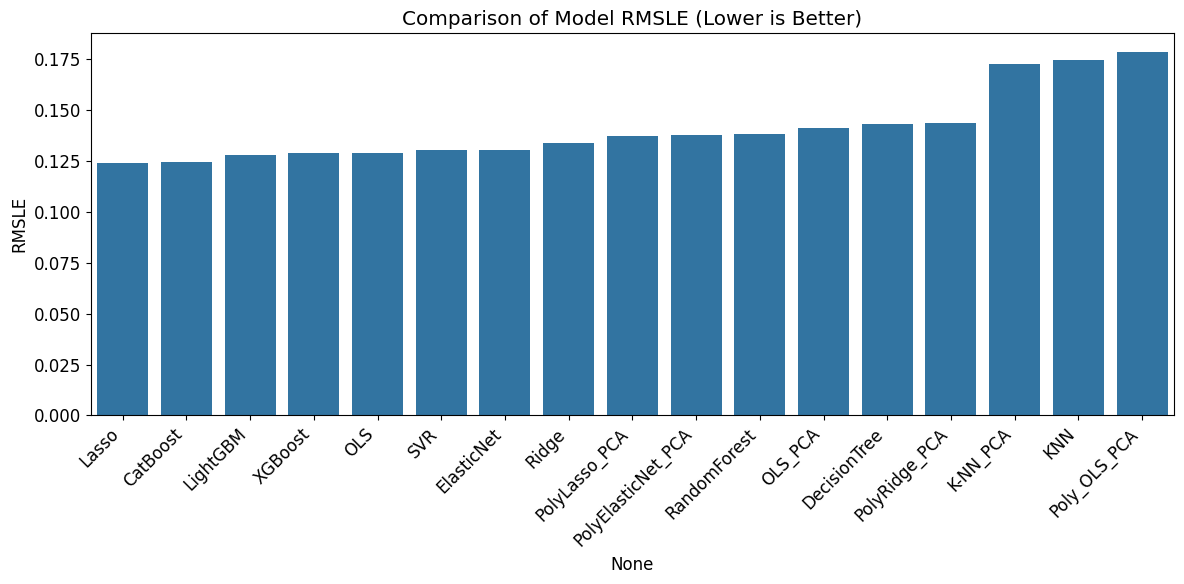

**Actual vs. predicted prices — `Lasso`**

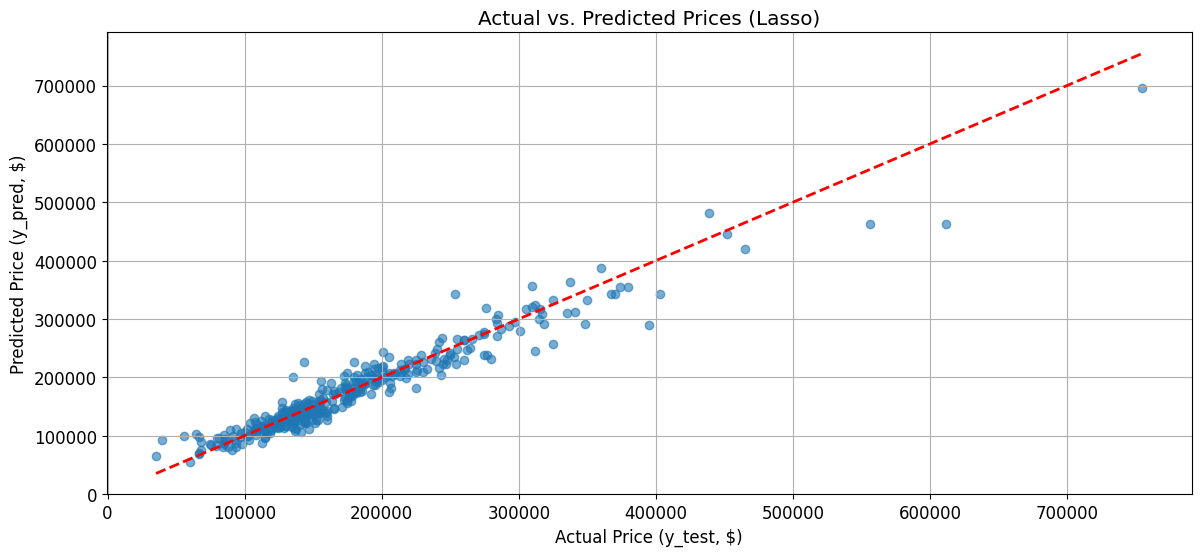

**Residual analysis — `Lasso`**

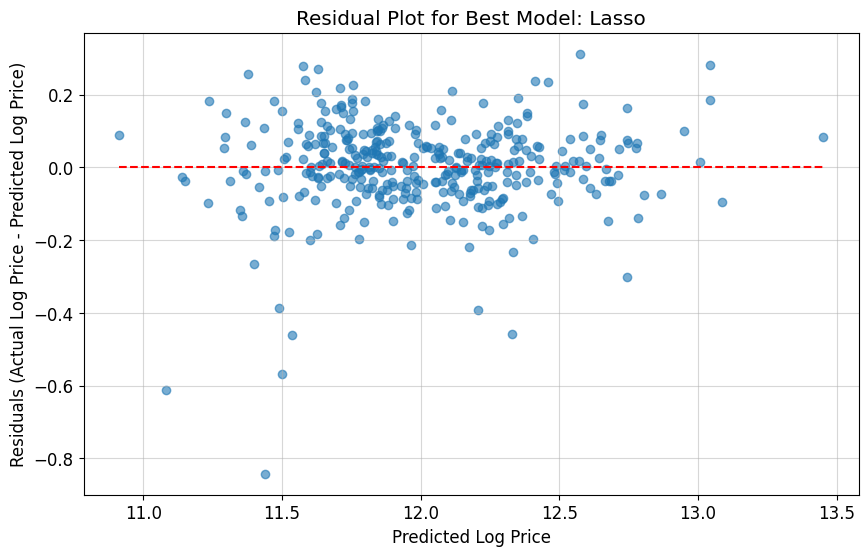

**Best model selection**

**Best model:** `Lasso`

**Best RMSLE:** `0.12375`

In [41]:
metrics_df = pd.DataFrame({
    name: {key: val for key, val in res.items() if key != 'y_pred'} 
    for name, res in results.items()}).T

md("**Final model evaluation and comparison**")
metrics_df_display = metrics_df.copy()
metrics_df_display["RMSE ($)"] = metrics_df_display["RMSE ($)"].round(0).astype(int)
metrics_df_display["MAE ($)"] = metrics_df_display["MAE ($)"].round(0).astype(int)

show_table("Summary metrics table (sorted by RMSLE ↓ better)",
           metrics_df_display.sort_values(by = "RMSLE", ascending = True),
           round_n = 5)

sorted_df = metrics_df.sort_values("RMSLE", ascending = True)

plt.figure(figsize = (12, 6))
sns.barplot(x = sorted_df.index, y = sorted_df["RMSLE"])
plt.title('Comparison of Model RMSLE (Lower is Better)')
plt.ylabel('RMSLE')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

best_model_name = metrics_df['RMSLE'].idxmin()
best_rmsle = metrics_df.loc[best_model_name, "RMSLE"]

md(f"**Actual vs. predicted prices — `{best_model_name}`**")
plt.figure(figsize = (14, 6))
plt.scatter(y_test, results[best_model_name]['y_pred'], alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw = 2)
plt.xlabel('Actual Price (y_test, $)')
plt.ylabel('Predicted Price (y_pred, $)')
plt.title(f'Actual vs. Predicted Prices ({best_model_name})')
plt.grid(True)
plt.show()

y_pred_log_best = np.log1p(results[best_model_name]['y_pred'])
residuals = y_test_log - y_pred_log_best

md(f"**Residual analysis — `{best_model_name}`**")
plt.figure(figsize = (10, 6))
plt.scatter(y_pred_log_best, residuals, alpha = 0.6)
plt.hlines(y = 0, xmin = y_pred_log_best.min(), xmax = y_pred_log_best.max(), color = 'red', linestyle = '--')
plt.xlabel('Predicted Log Price')
plt.ylabel('Residuals (Actual Log Price - Predicted Log Price)')
plt.title(f'Residual Plot for Best Model: {best_model_name}')
plt.grid(True, alpha = 0.5)
plt.show()

md("**Best model selection**")
show_kv("Best model", best_model_name)
show_kv("Best RMSLE", round(float(best_rmsle), 5))

- The final comparison highlights clear differences in how various model families generalize on the housing price prediction task.
- Regularized linear models demonstrate unexpectedly strong performance.
- In particular, `Lasso` emerges as the top-performing model, indicating that the underlying signal in the data is largely linear and can be captured effectively through sparse feature selection. The L1 penalty suppresses noisy and redundant features introduced by extensive one-hot encoding, leading to strong generalization despite the model’s simplicity.
- Tree-based boosting models (`CatBoost`, `XGBoost`, and `LightGBM`) form a close second tier.
- These models consistently outperform most alternatives by capturing non-linear effects and complex feature interactions. Among them, `CatBoost` stands out due to its native handling of categorical features and robust regularization strategy, delivering performance comparable to the best linear model while maintaining higher modeling flexibility.
- Classical linear regression without regularization performs competitively but is less stable, confirming the importance of explicit regularization in high-dimensional settings.
- Distance-based and polynomial models consistently underperform, primarily due to sensitivity to dimensionality, noise, and feature correlation.

**Final model choice**

- Despite the strong performance of gradient boosting models, `Lasso regression` is selected as the final model for generating predictions on unseen data.
- This choice is motivated by:
    - its superior generalization performance,
    - robustness to high-dimensional sparse feature representations,
    - implicit feature selection through L1 regularization,
    - simplicity, interpretability, and lower risk of overfitting.
- While `CatBoost` represents a strong alternative and would be preferable in scenarios requiring richer non-linear modeling, the empirical results indicate that, for this dataset, the additional complexity does not yield a meaningful improvement over a well-regularized linear approach.
- For structured tabular data with extensive categorical encoding, model simplicity combined with strong regularization can outperform more complex non-linear methods.
- This experiment underscores the importance of establishing strong linear baselines and selecting models based on empirical generalization rather than perceived sophistication.

<a id="feature-importance-analysis"></a>
## Feature importance analysis

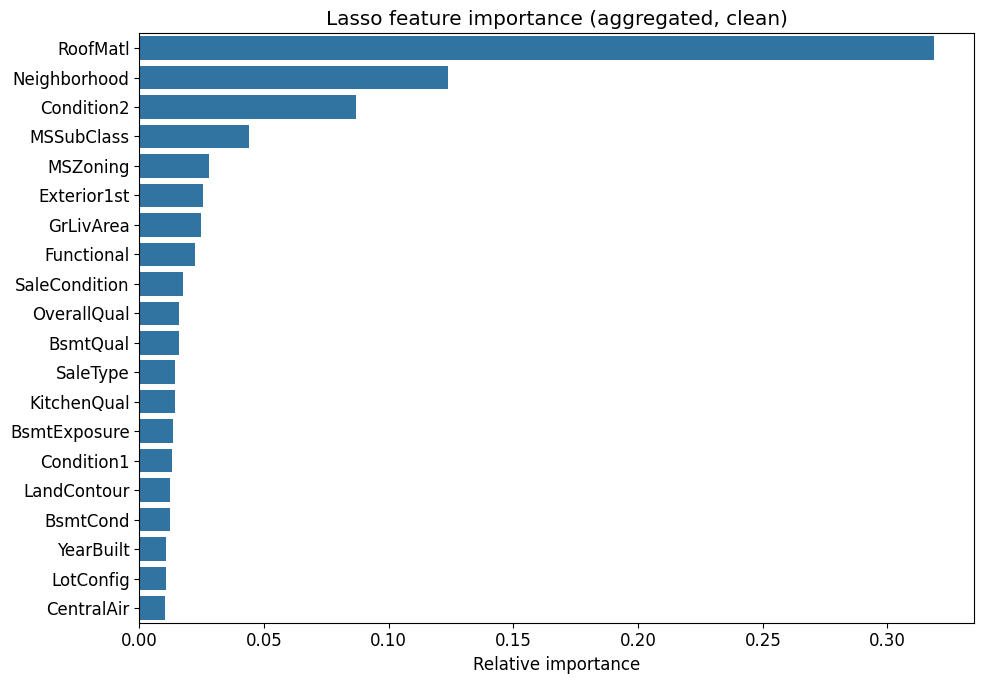

,feature,importance,cum_importance
0,RoofMatl,0.318761,0.318761
1,Neighborhood,0.123622,0.442383
2,Condition2,0.086873,0.529256
3,MSSubClass,0.043981,0.573236
4,MSZoning,0.028067,0.601303
5,Exterior1st,0.025458,0.626761
6,GrLivArea,0.024543,0.651304
7,Functional,0.022378,0.673683
8,SaleCondition,0.017573,0.691255
9,OverallQual,0.015784,0.707039


In [42]:
def lasso_feature_importance_clean(pipeline, X_sample, cumulative_threshold = 0.95, min_features = 5, max_features = 20):
    '''The function computes aggregated feature importance for a Lasso model using absolute coefficient values.'''

    # Extract fitted preprocessing and Lasso steps from the pipeline
    preprocessor = pipeline.named_steps["preprocessor"]
    lasso = pipeline.named_steps["regressor"]

    # Get feature names after preprocessing (including one-hot encoding)
    feature_names = preprocessor.get_feature_names_out(X_sample.columns)
    
    # Absolute Lasso coefficients are used as a proxy for feature importance
    coefs = np.asarray(lasso.coef_).ravel()

    df = pd.DataFrame({
        "feature_ohe": feature_names,
        "abs_coef": np.abs(coefs)})

    # Map one-hot encoded features back to their original feature names
    def clean_name(name: str) -> str:
        '''The function converts a preprocessed feature name to its original feature name by removing pipeline prefixes and one-hot encoded levels.'''
        
        if "__" in name:
            name = name.split("__", 1)[1]
        if "_" in name:
            return name.split("_", 1)[0]
        return name

    df["feature"] = df["feature_ohe"].apply(clean_name)

    # Aggregate importance across one-hot encoded levels
    grouped = (df.groupby("feature", as_index = False)["abs_coef"].sum().sort_values("abs_coef", ascending = False).reset_index(drop = True))

    # Normalize importance and compute cumulative contribution
    grouped["importance"] = grouped["abs_coef"] / grouped["abs_coef"].sum()
    grouped["cum_importance"] = grouped["importance"].cumsum()

    # Select features up to the cumulative importance threshold
    selected = grouped[grouped["cum_importance"] <= cumulative_threshold]

    # Enforce minimum and maximum number of displayed features
    if len(selected) < min_features:
        selected = grouped.head(min_features)
    if len(selected) > max_features:
        selected = selected.head(max_features)

    # Plot aggregated feature importance
    plt.figure(figsize = (10, 7))
    sns.barplot(
        data = selected,
        x = "importance",
        y = "feature")
    plt.title("Lasso feature importance (aggregated, clean)")
    plt.xlabel("Relative importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    return selected[["feature", "importance", "cum_importance"]]


best_model = final_pipelines[best_model_name]
clean_importance = lasso_feature_importance_clean(
    best_model,
    X_train_train,
    cumulative_threshold = 0.95,
    min_features = 5,
    max_features = 20)
display(clean_importance)

#### Feature importance analysis

- The feature importance analysis confirms that the Lasso model relies primarily on a limited set of strong predictors, with importance concentrated in a small number of categorical and structural features.
- High-level property characteristics such as roof material, location, zoning, and overall quality dominate the model, while size-related variables play a secondary but stable role.
- The cumulative importance distribution indicates that most of the predictive signal is captured by a relatively compact subset of features, supporting the effectiveness of L1 regularization in suppressing redundant and weak predictors.
- Overall, the results are consistent with the model’s strong generalization performance and highlight that housing prices in this dataset are driven more by qualitative attributes and location than by fine-grained numeric details.

<a id="final-prediction-and-submission-file-generation"></a>
## Final prediction and submission file generation

In [43]:
y_pred_log = best_model.predict(X_test) 

y_pred_original = np.expm1(y_pred_log) 
y_pred_original[y_pred_original < 0] = 0 

submission_df = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': y_pred_original})

md("**Final prediction and submission file generation**")
show_df("First 5 predictions", submission_df, head = 5)

submission_file_name = f'submission_{best_model_name}.csv'
submission_df.to_csv(submission_file_name, index = False)
show_kv("Submission file saved", submission_file_name)

**Final prediction and submission file generation**

**First 5 predictions**

,Id,SalePrice
0,1461,116608.367092
1,1462,133143.855149
2,1463,171509.856635
3,1464,195487.886038
4,1465,203712.354442


**Submission file saved:** `submission_Lasso.csv`

- The final model is used to generate predictions for the test dataset, and the resulting submission file is prepared in the required format for evaluation on unseen data.